In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("result_shapes.csv")
df.head(5)

,M,N,K,case_name,kernel,tiling_key,singleCoreM,singleCoreN,singleCoreK,baseM,...,stepKa,stepKb,iterateOrder,dbL0A,dbL0B,dbL0C,mTileBlock,nTileBlock,nd2nzA,nd2nzB
0,1,1536,7168,query_down_proj_1_7168_1536,BASE_FULLLOAD + MIXND2NZ_FALSE,65536,16,128,7168,16,...,32,4,0,2,2,1,1,12,0,0
1,1,16384,1536,query_up_proj_nope_1_1536_16384,BASE_FULLLOAD + MIXND2NZ_FALSE,65536,16,256,1536,16,...,64,4,0,2,2,1,1,64,0,0
2,1,8192,1536,query_up_proj_rope_1_1536_8192,BASE_FULLLOAD + MIXND2NZ_FALSE,65536,16,128,1536,16,...,32,4,0,2,2,1,1,64,0,0
3,1,24576,1536,query_up_proj_fused_1_1536_24576,BASE_FULLLOAD + MIXND2NZ_FALSE,65536,16,512,1536,16,...,128,4,0,2,2,1,1,48,0,0
4,1,512,7168,kv_down_proj_1_7168_512,BASE_FULLLOAD + MIXND2NZ_FALSE,65536,16,128,7168,16,...,32,4,0,2,2,1,1,4,0,0


In [6]:
need_shapes = (
    ((df['M'] == 1) | (df['M'] == 64) | (df['M'] == 128) | (df['M'] == 256) | (df['M'] == 384) | (df['M'] == 512)) &
    ((df['N'] == 64) | (df['N'] == 128) | (df['N'] == 256) | (df['N'] == 384) | (df['N'] == 512)) &
    (df['K'] == 7168)
)

filtered_df = df[need_shapes]
filtered_df.to_csv('base_brute.csv', index=False)

In [3]:
base_fulload_nd2nzB = df[df['kernel'] == 'BASE_FULLLOAD']
base_fulload = df[df['kernel'] == 'BASE_FULLLOAD + MIXND2NZ_FALSE']
single_split_nd2nzA = df[df['kernel'] == 'BASE_FULLLOAD + SINGLE_CORE_SPLIT_K']
determenistic_split_nd2nzA = df[df['kernel'] == 'BASE_FULLLOAD + DETERMINISTIC_SPLIT_K']

In [4]:
res = (
    df.groupby(['N', 'K'])['kernel']
    .agg(
        count='nunique',
        kernels=lambda x: list(x.unique())
    )
    .query('count > 1')
    .reset_index()[['N', 'K', 'kernels']]
)

print(res)

        N      K                                            kernels
0    7168  65536  [BASE_FULLLOAD + DETERMINISTIC_SPLIT_K, BASE_F...
1   36864   7168  [BASE_FULLLOAD + MIXND2NZ_FALSE, BASE_FULLLOAD...
2   65536   1536  [BASE_FULLLOAD, BASE_FULLLOAD + SINGLE_CORE_SP...
3  129280   7168  [BASE_FULLLOAD, BASE_FULLLOAD + SINGLE_CORE_SP...


In [5]:
df['kernel'].unique()

<StringArray>
[                               'BASE_FULLLOAD + MIXND2NZ_FALSE',
                         'BASE_FULLLOAD + DETERMINISTIC_SPLIT_K',
                                                 'BASE_FULLLOAD',
                           'BASE_FULLLOAD + SINGLE_CORE_SPLIT_K',
 'BASE_FULLLOAD + SINGLE_CORE_SPLIT_K_GM_TO_L1 + MIXND2NZ_FALSE',
                  'BASE_FULLLOAD + SINGLE_CORE_SPLIT_K_GM_TO_L1']
Length: 6, dtype: str

In [6]:
sub = df[df.kernel.str.contains('DETERMINISTIC')]
print(sub[['nd2nzA','nd2nzB','tiling_key']].drop_duplicates())

   nd2nzA  nd2nzB  tiling_key
9       1       0          48


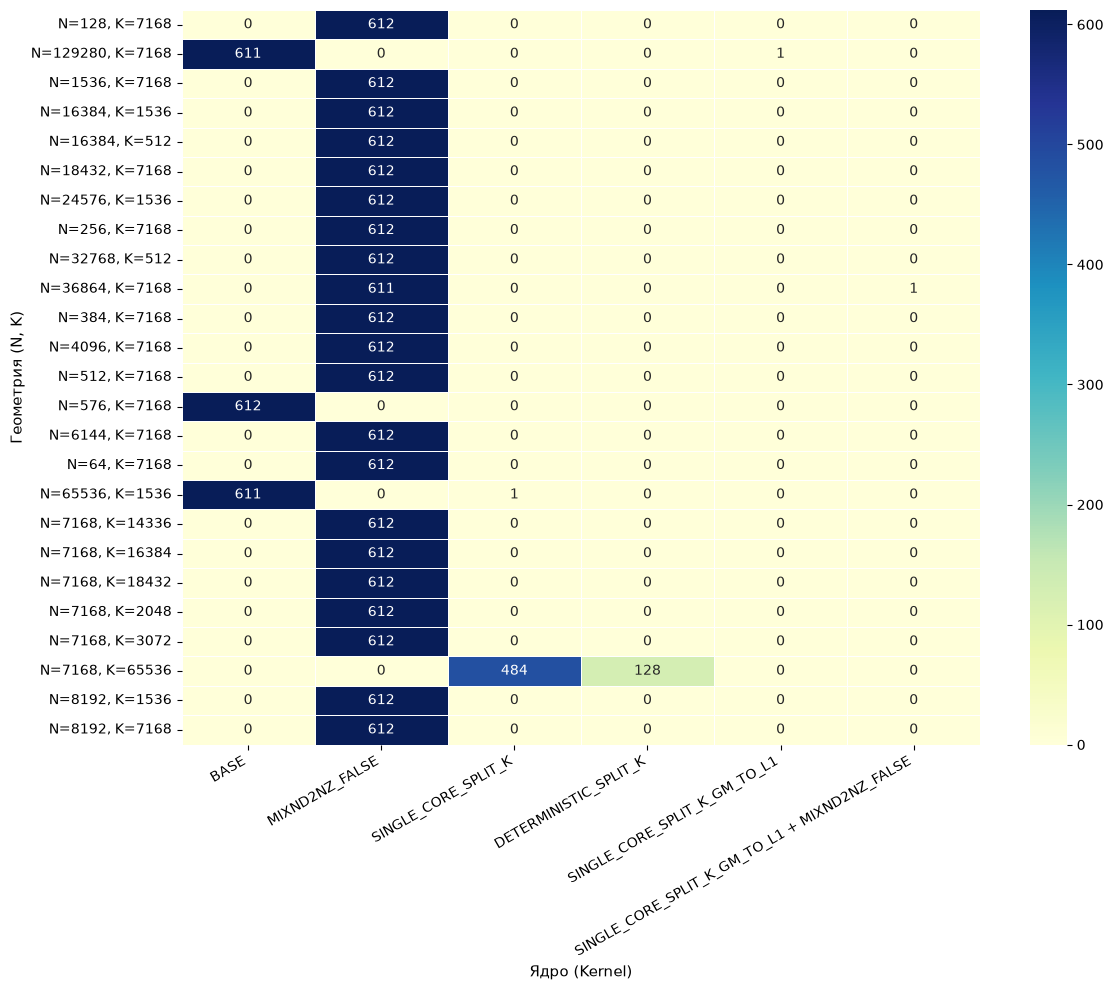

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Фильтруем нужные ядра
kernels = [
    'BASE_FULLLOAD',
    'BASE_FULLLOAD + MIXND2NZ_FALSE',
    'BASE_FULLLOAD + SINGLE_CORE_SPLIT_K',
    'BASE_FULLLOAD + DETERMINISTIC_SPLIT_K',
    'BASE_FULLLOAD + SINGLE_CORE_SPLIT_K_GM_TO_L1',
    'BASE_FULLLOAD + SINGLE_CORE_SPLIT_K_GM_TO_L1 + MIXND2NZ_FALSE',
]

df_sub = df[df['kernel'].isin(kernels)].copy()

# 2. Создаем понятную метку для пар (N, K)
df_sub['NK'] = 'N=' + df_sub['N'].astype(str) + ', K=' + df_sub['K'].astype(str)

# 3. Строим сводную таблицу: подсчитываем количество уникальных M для каждой пары (N, K) и ядра
pivot_df = df_sub.pivot_table(
    index='NK', columns='kernel', values='M', aggfunc='nunique', fill_value=0
)

# Выравниваем порядок колонок в соответствии со списком kernels
pivot_df = pivot_df.reindex(columns=kernels, fill_value=0)

# 4. Сокращаем названия ядер для красивого отображения на графике
short_columns = [
    k.replace('BASE_FULLLOAD + ', '').replace('BASE_FULLLOAD', 'BASE')
    for k in kernels
]
pivot_df_display = pivot_df.copy()
pivot_df_display.columns = short_columns

# 5. Визуализация
# Динамически подстраиваем высоту фигуры под количество пар (N, K)
fig_height = max(6, len(pivot_df) * 0.4)
plt.figure(figsize=(12, fig_height))

sns.heatmap(
    pivot_df_display,
    annot=True,
    fmt='d',  # Целые числа (количество M)
    cmap='YlGnBu',
    linewidths=0.5,
)
plt.xlabel('Ядро (Kernel)', fontsize=11)
plt.ylabel('Геометрия (N, K)', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

**Выводы:**
1) base + nd2nzB выбирается, когда или N не выровнено, или оно слишком большое
2) splitK выбирается только в 1 случае и singleCore или deterministic зависит от M уже
3) GM_T_L1 - скорее исключительные случаи попадания для нас
4) Также было замечено, что deterministic split K работает скорее на малых значениях (M <= 128)

**Вывод:** на выбор тайлинга влияет только N и K

In [8]:
COLUMNS_TILING = ['singleCoreM', 'singleCoreN', 'singleCoreK', 'baseM', 'baseN', 'baseK',
                  'stepM', 'stepN', 'stepKa', 'stepKb', 'iterateOrder',
                  'dbL0A', 'dbL0B', 'dbL0C', 'mTileBlock', 'nTileBlock', 'nd2nzA', 'nd2nzB']

In [9]:
def print_unique_values(df: pd.DataFrame):
    for col in COLUMNS_TILING:
        print(f"{col}: {[int(x) for x in df[col].unique()]}")
    unique = (df['N'].astype(str) + 'x' + df['K'].astype(str)).unique()
    print(f"NxK: {[x for x in unique]}")

In [10]:
print_unique_values(base_fulload)

singleCoreM: [16, 32, 48, 64, 112, 128, 80, 96]
singleCoreN: [128, 256, 512, 64]
singleCoreK: [7168, 1536, 512, 16384, 18432, 2048, 14336, 3072]
baseM: [16, 32, 48, 64, 112, 128, 80, 96]
baseN: [128, 256, 512, 64]
baseK: [128, 64, 32]
stepM: [1]
stepN: [1]
stepKa: [32, 64, 128, 16, 20, 8, 40, 4, 12]
stepKb: [4, 16, 8, 12]
iterateOrder: [0]
dbL0A: [2]
dbL0B: [2]
dbL0C: [1]
mTileBlock: [1, 2, 3, 4, 7, 8, 5, 9, 10, 6, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 33, 39, 40, 34, 41, 35, 42, 27, 36, 43, 44, 28, 32, 45, 29, 46, 47, 30, 48, 31, 37, 38, 49, 66, 50, 67, 51, 68, 52, 70, 53, 71, 54, 55, 56]
nTileBlock: [12, 64, 48, 4, 256, 1, 6, 2, 16, 56, 3, 24, 96, 128, 32, 28, 192, 10, 7, 26]
nd2nzA: [0]
nd2nzB: [0]
NxK: ['1536x7168', '16384x1536', '8192x1536', '24576x1536', '512x7168', '16384x512', '32768x512', '64x7168', '7168x16384', '18432x7168', '36864x7168', '7168x18432', '256x7168', '4096x7168', '7168x2048', '7168x14336', '8192x7168', '128x7168', '384x7168', '6144x716

<Axes: >

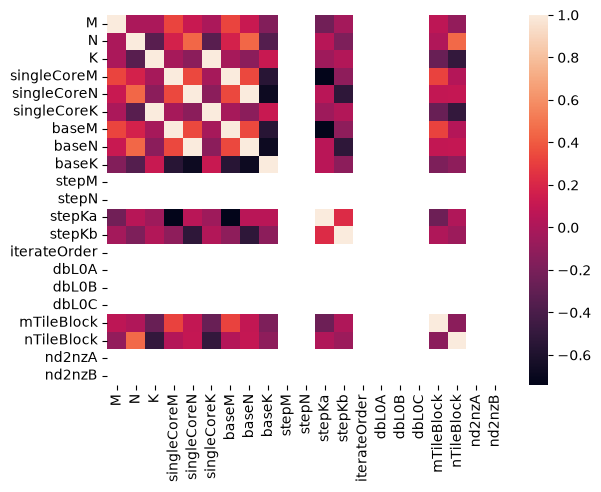

In [11]:
sns.heatmap(base_fulload[['M', 'N', 'K'] + COLUMNS_TILING].corr())

In [12]:
print_unique_values(base_fulload_nd2nzB)

singleCoreM: [16, 32, 48, 64, 112, 128, 96, 80]
singleCoreN: [512, 32, 256, 128, 48]
singleCoreK: [7168, 1536]
baseM: [16, 32, 48, 64, 112, 128, 96, 80]
baseN: [512, 32, 256, 128, 48]
baseK: [32, 64]
stepM: [1]
stepN: [1]
stepKa: [128, 64, 32, 40, 20, 8, 16, 12]
stepKb: [4, 32, 8, 20, 16]
iterateOrder: [0]
dbL0A: [2]
dbL0B: [2]
dbL0C: [1]
mTileBlock: [1, 2, 3, 4, 9, 6, 7, 8, 5, 13, 14, 15, 10, 16, 11, 12, 22, 17, 23, 18, 24, 21, 19, 20, 28, 25, 29, 26, 30, 27, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
nTileBlock: [6, 18, 12, 5, 17, 16, 3]
nd2nzA: [0]
nd2nzB: [1]
NxK: ['129280x7168', '576x7168', '65536x1536']


<Axes: >

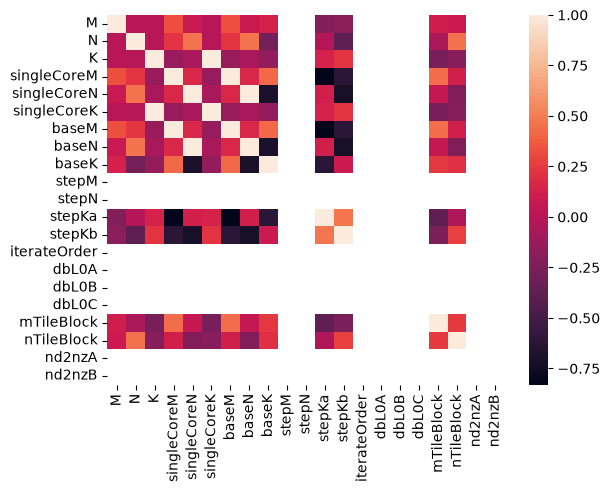

In [13]:
sns.heatmap(base_fulload_nd2nzB[['M', 'N', 'K'] + COLUMNS_TILING].corr())

In [14]:
print_unique_values(single_split_nd2nzA)

singleCoreM: [80, 96, 112, 128, 192, 384, 208, 224, 240, 256, 176, 272, 288, 304, 320, 336, 352, 368, 400, 416, 432, 448, 464, 480, 496, 512, 528, 544, 560, 576, 592, 608, 624, 640, 656, 672, 688, 704, 720, 736, 752, 768, 784, 800, 816, 832, 848, 864, 880, 896, 912, 928, 944, 960, 976, 992, 1008, 1024, 1040, 1056, 1072, 1088, 1104, 1120, 1136, 1152, 1168, 1184, 1200, 1216, 1232, 1248, 1264, 1280, 1296, 1312, 1328, 1344, 1360, 1376, 1392, 1408, 1424, 1440, 1456, 1472, 1488, 1504, 1520, 1536, 1552, 1568, 1584, 1600, 1616, 1632, 1648, 1664, 1680, 1696, 1712, 1728, 1744, 1760, 1776, 1792, 1808, 1824, 1840, 1856, 1872, 1888, 1904, 1920, 1936, 1952, 1968, 1984, 2000, 2016, 2032, 2048, 2112, 2176, 2240, 2304, 2368, 2432, 2496, 2560, 2624, 2688, 2752, 2816, 2880, 2944, 3008, 3072, 3136, 3200, 3264, 3328, 3392, 3456, 3520, 3584, 3648, 3712, 3776, 3840, 3904, 3968, 4032, 4096, 4160, 4224, 4288, 4352, 4416, 4480, 4544, 4608, 4672, 4736, 4800, 4864, 4928, 4992, 5056, 5120, 5184, 5248, 5312, 5376, 

<Axes: >

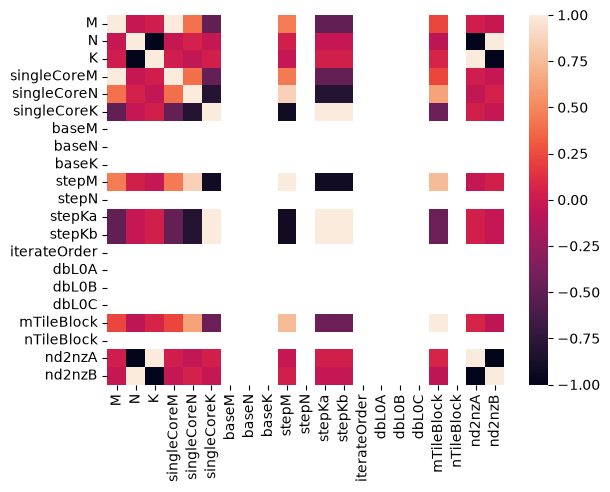

In [15]:
sns.heatmap(single_split_nd2nzA[['M', 'N', 'K'] + COLUMNS_TILING].corr())

In [16]:
def plot_kernel_params(kernel_df: pd.DataFrame, plot_params: list = None):
    """Строит графики зависимостей параметров от M для всех уникальных пар (N, K)."""
    if plot_params is None:
        plot_params = COLUMNS_TILING
    kernel_name = (
        kernel_df['kernel'].iloc[0]
        if not kernel_df.empty
        else 'Unknown Kernel'
    )

    LINE_COLOR = '#2a78d6'
    GRID_COLOR = '#e1e0d9'
    AXIS_COLOR = '#c3c2b7'
    TEXT_COLOR = '#3d3d3a'

    nk_pairs = (
        kernel_df[['N', 'K']]
        .drop_duplicates()
        .sort_values(['N', 'K'])
        .to_numpy()
    )

    for n_val, k_val in nk_pairs:
        sub = kernel_df[
            (kernel_df['N'] == n_val) & (kernel_df['K'] == k_val)
        ].sort_values('M')

        fig, axes = plt.subplots(3, 6, figsize=(22, 10))
        fig.suptitle(
            f'{kernel_name} — N={n_val}, K={k_val}',
            fontsize=13,
            color=TEXT_COLOR,
        )

        flat_axes = axes.flat

        for i, param in enumerate(plot_params):
            ax = flat_axes[i]
            ax.plot(sub['M'], sub[param], color=LINE_COLOR, linewidth=1.8)
            ax.set_title(param, fontsize=11, color=TEXT_COLOR)
            ax.set_xlabel('M', fontsize=9, color=TEXT_COLOR)
            ax.grid(True, color=GRID_COLOR, linewidth=0.8)
            ax.set_axisbelow(True)

            for spine in ('top', 'right'):
                ax.spines[spine].set_visible(False)
            for spine in ('left', 'bottom'):
                ax.spines[spine].set_color(AXIS_COLOR)

            ax.tick_params(colors=TEXT_COLOR, labelsize=8)

        for j in range(len(plot_params), len(flat_axes)):
            flat_axes[j].set_visible(False)

        fig.tight_layout(rect=[0, 0, 1, 0.94])
        plt.show()

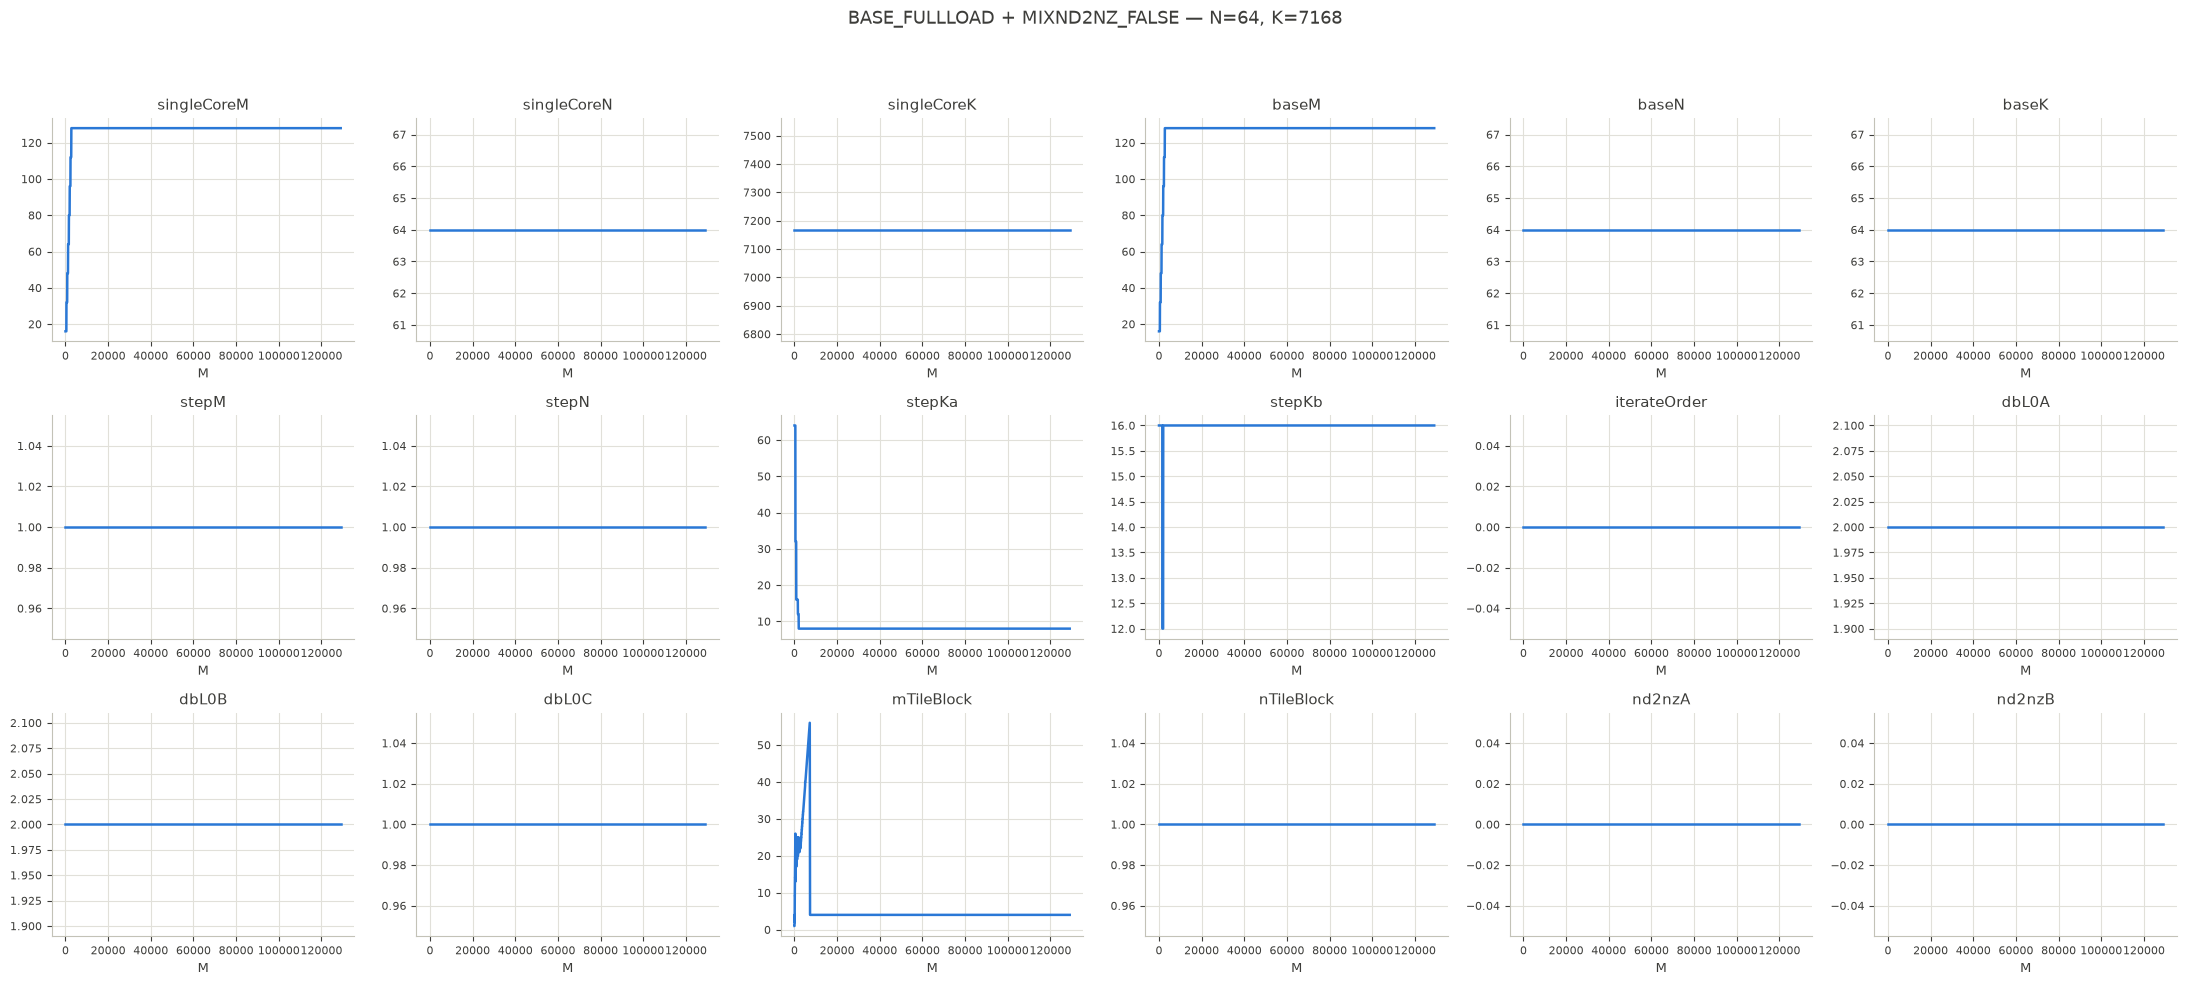

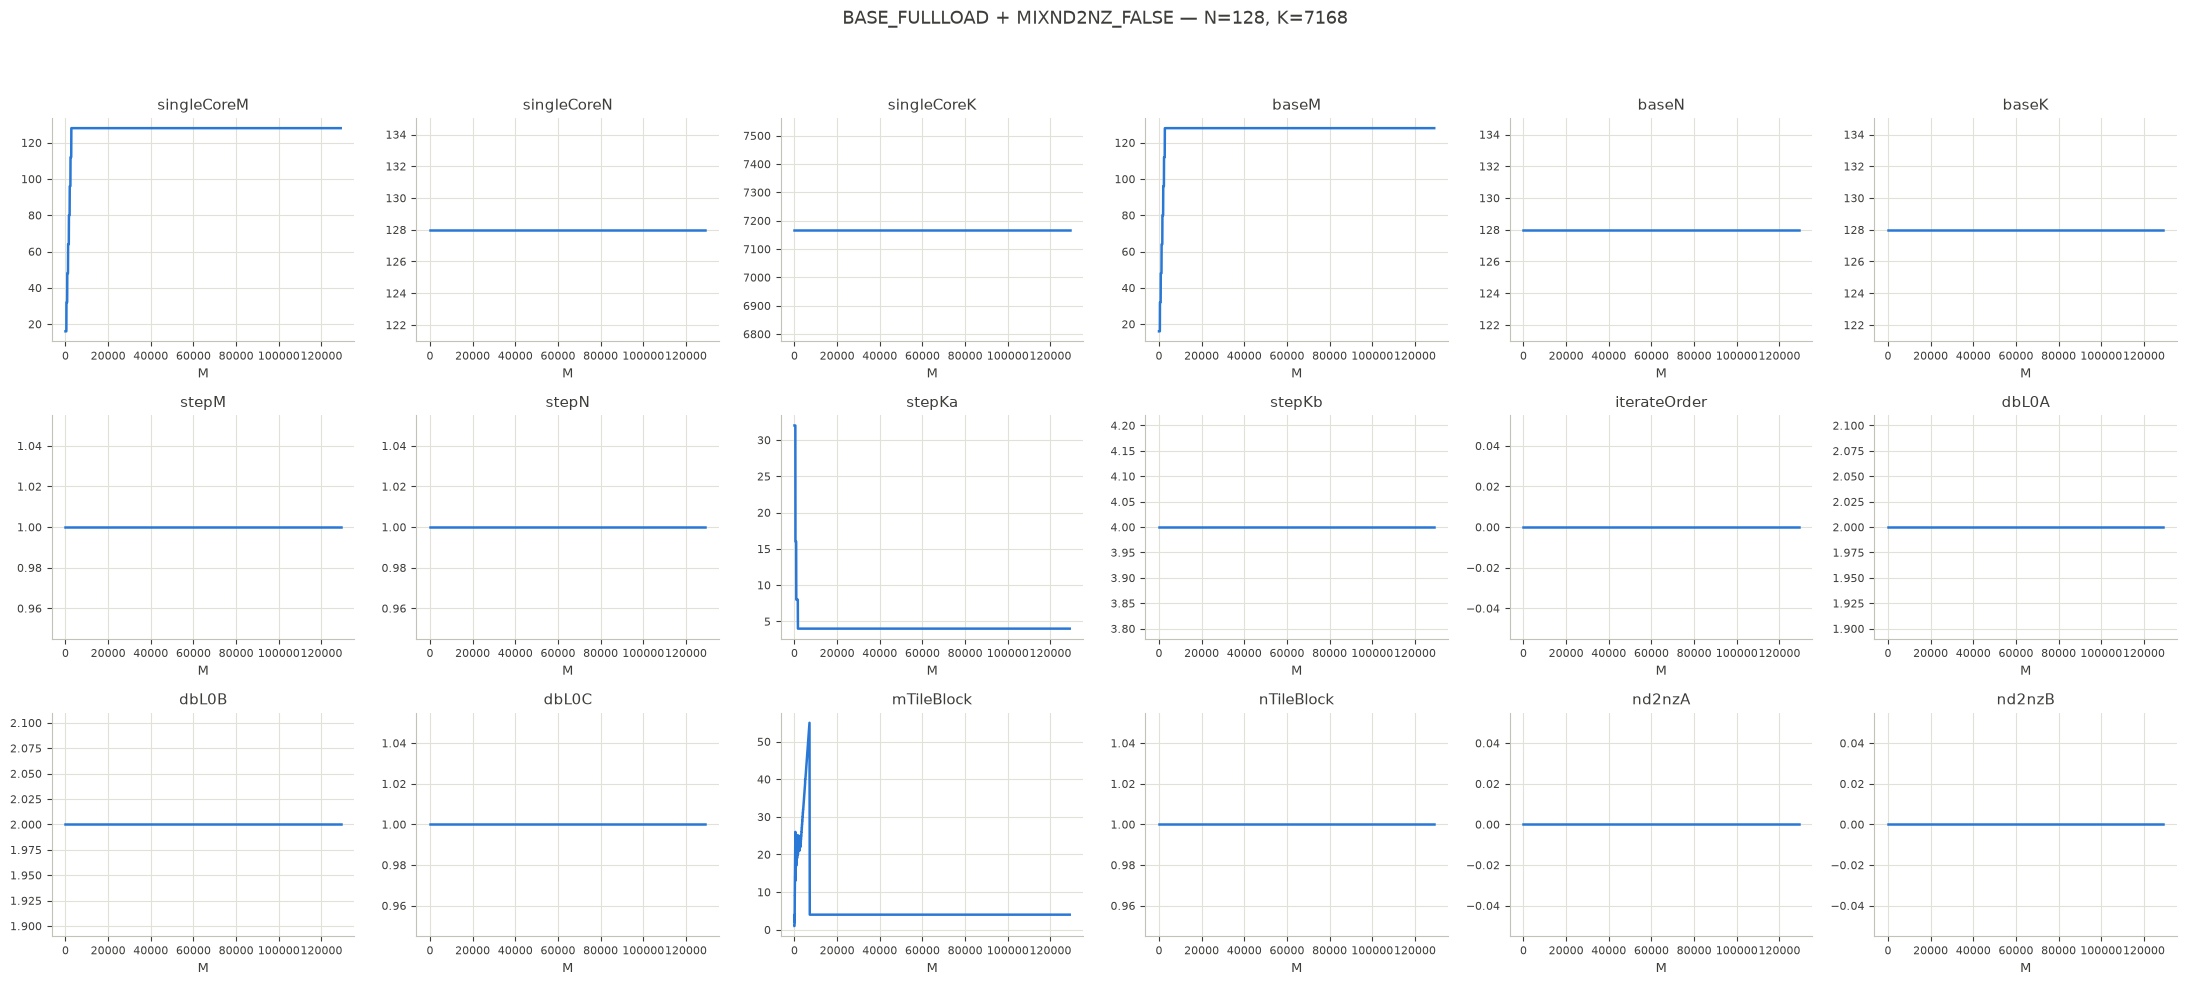

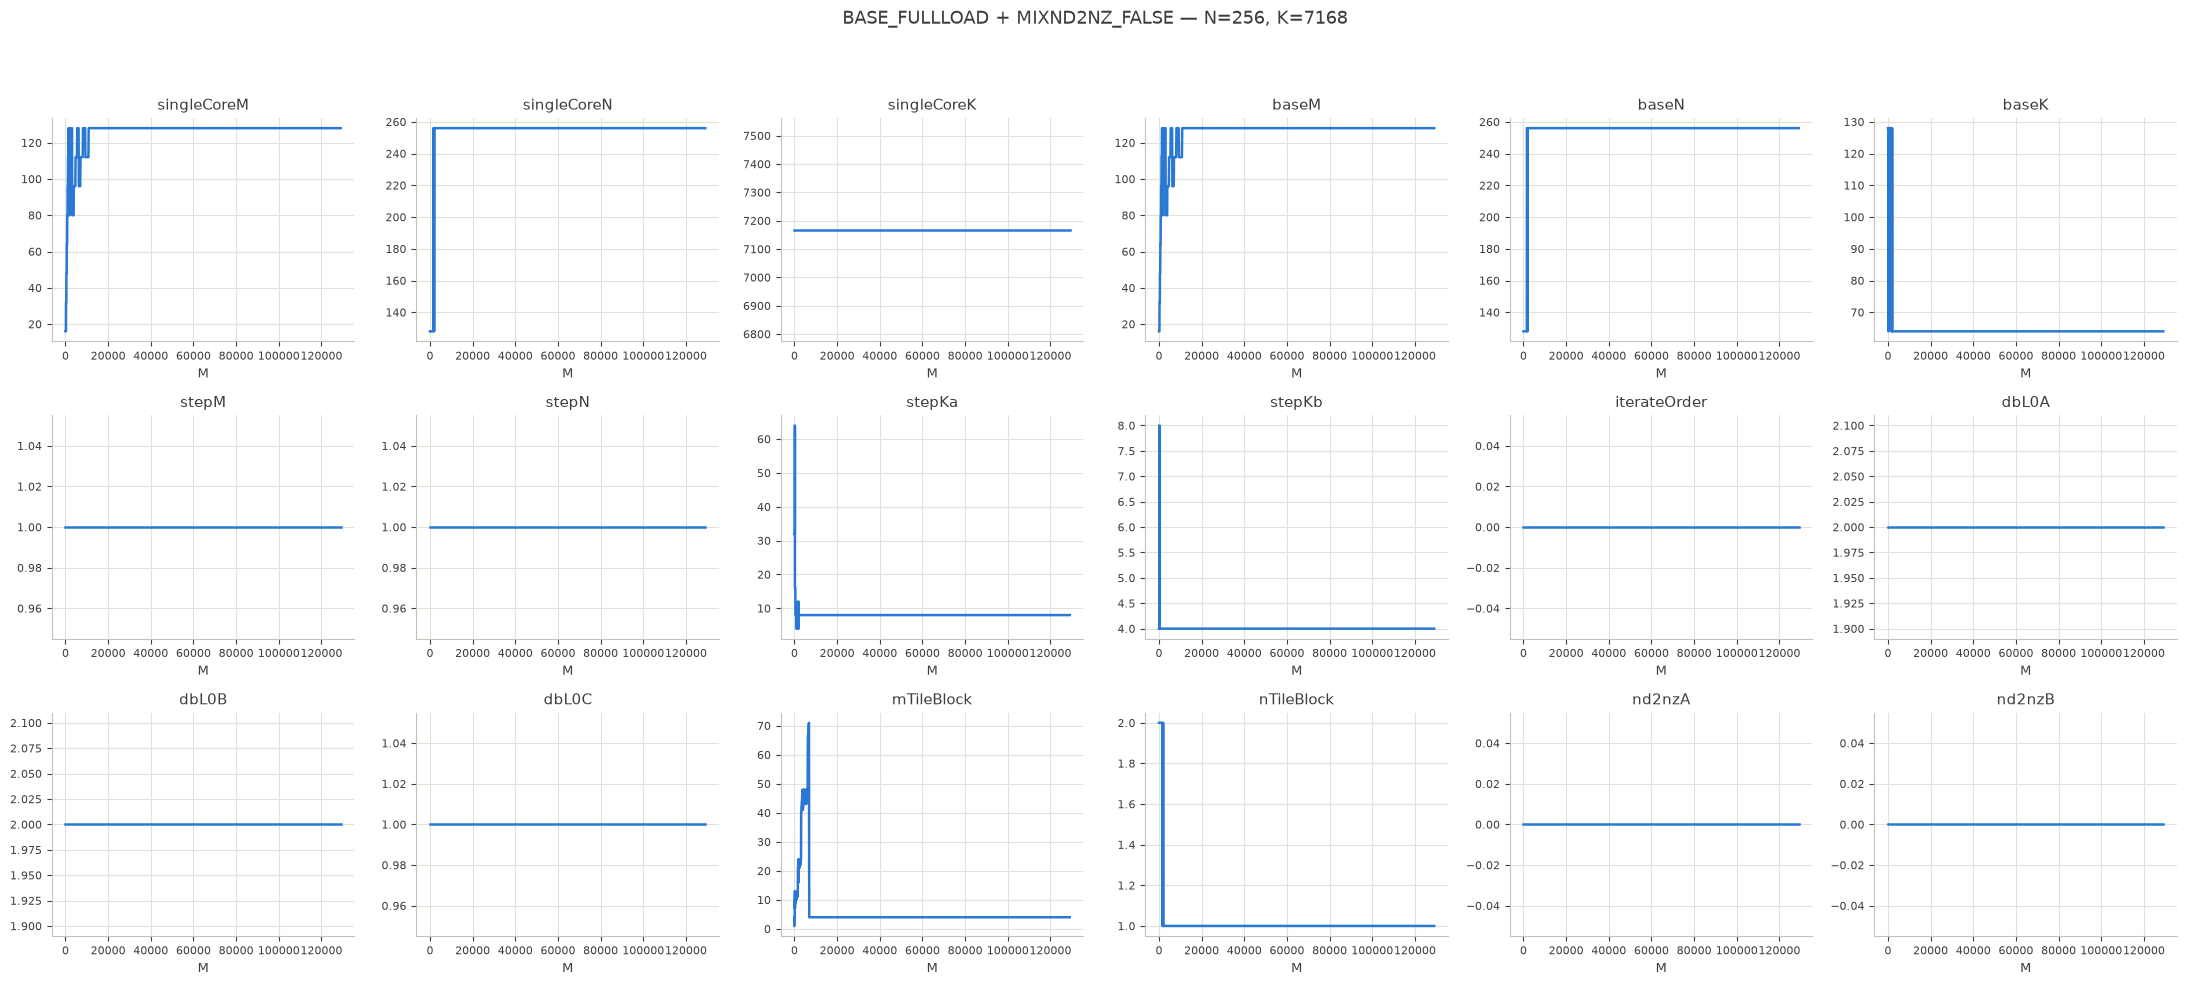

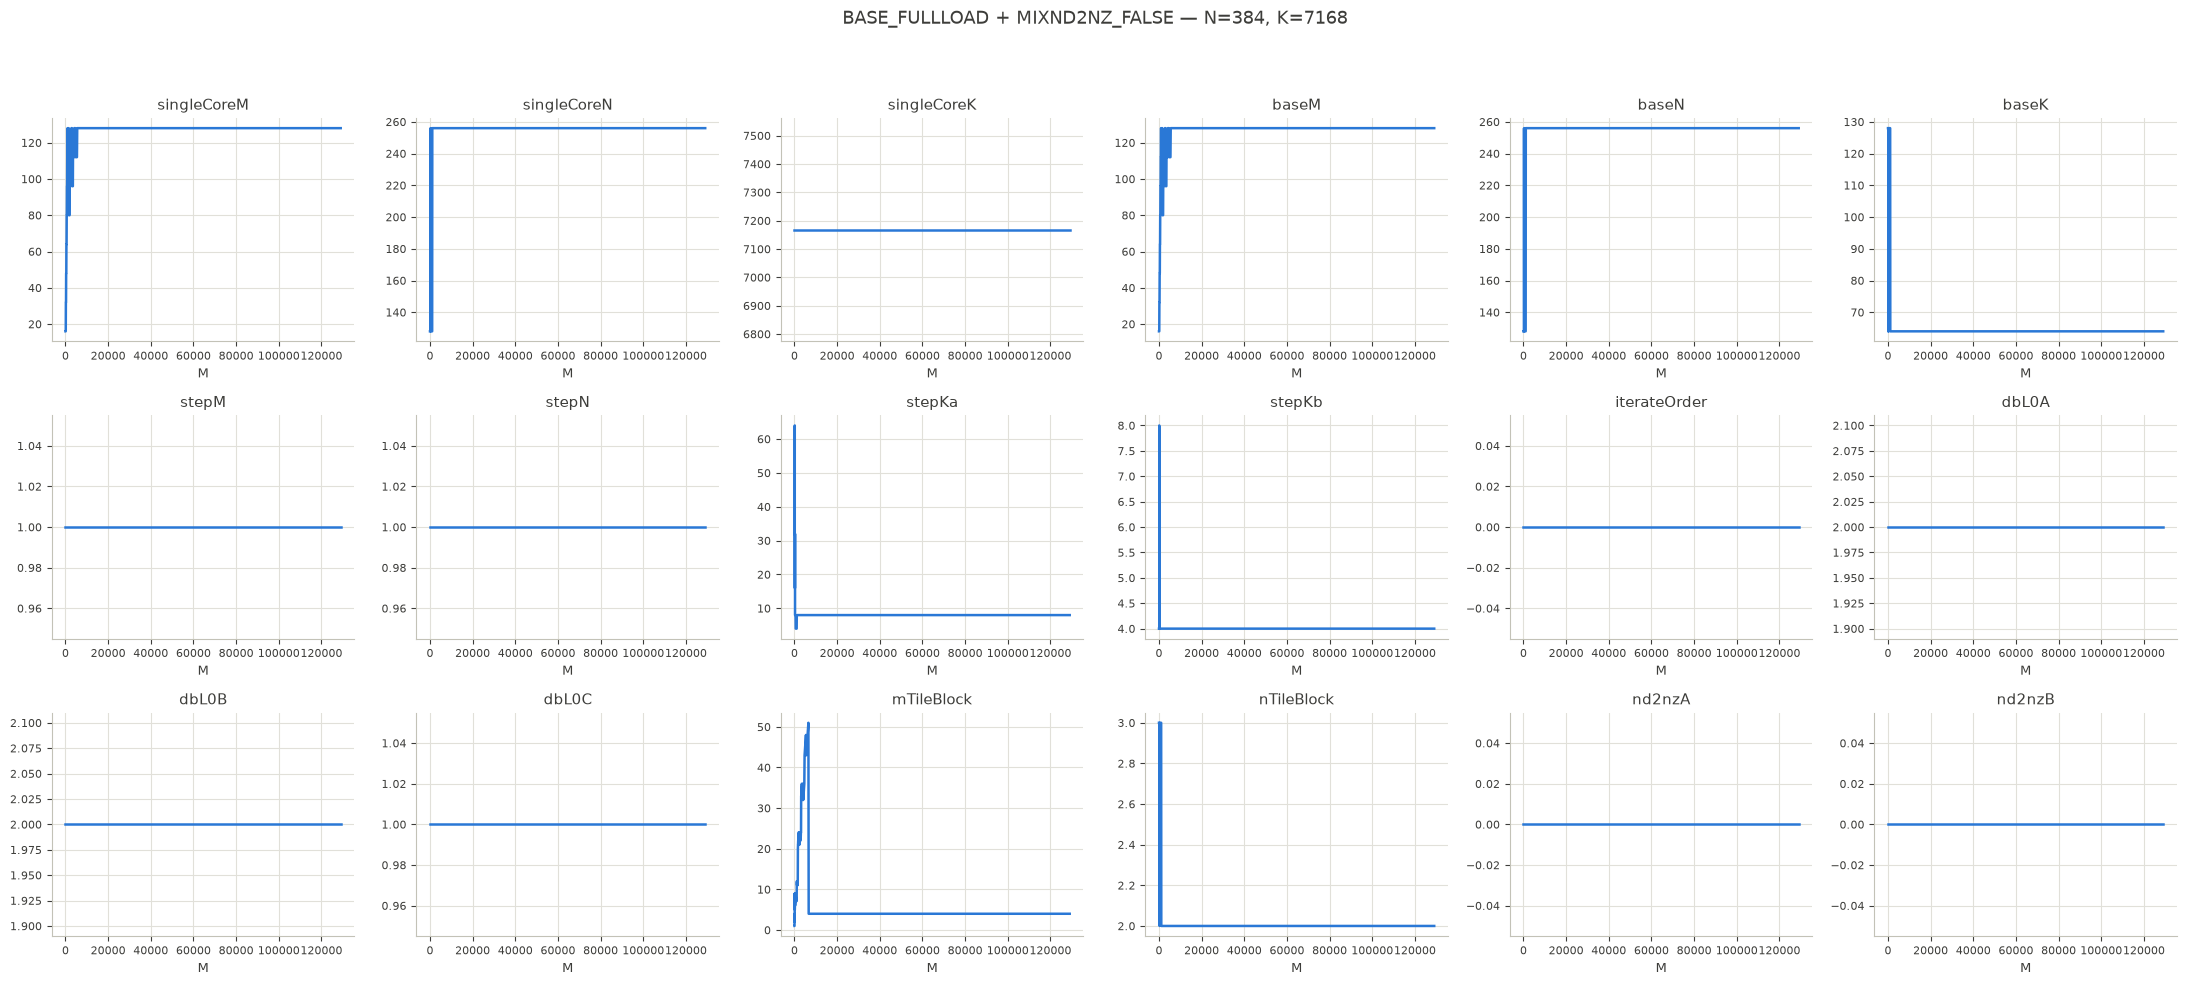

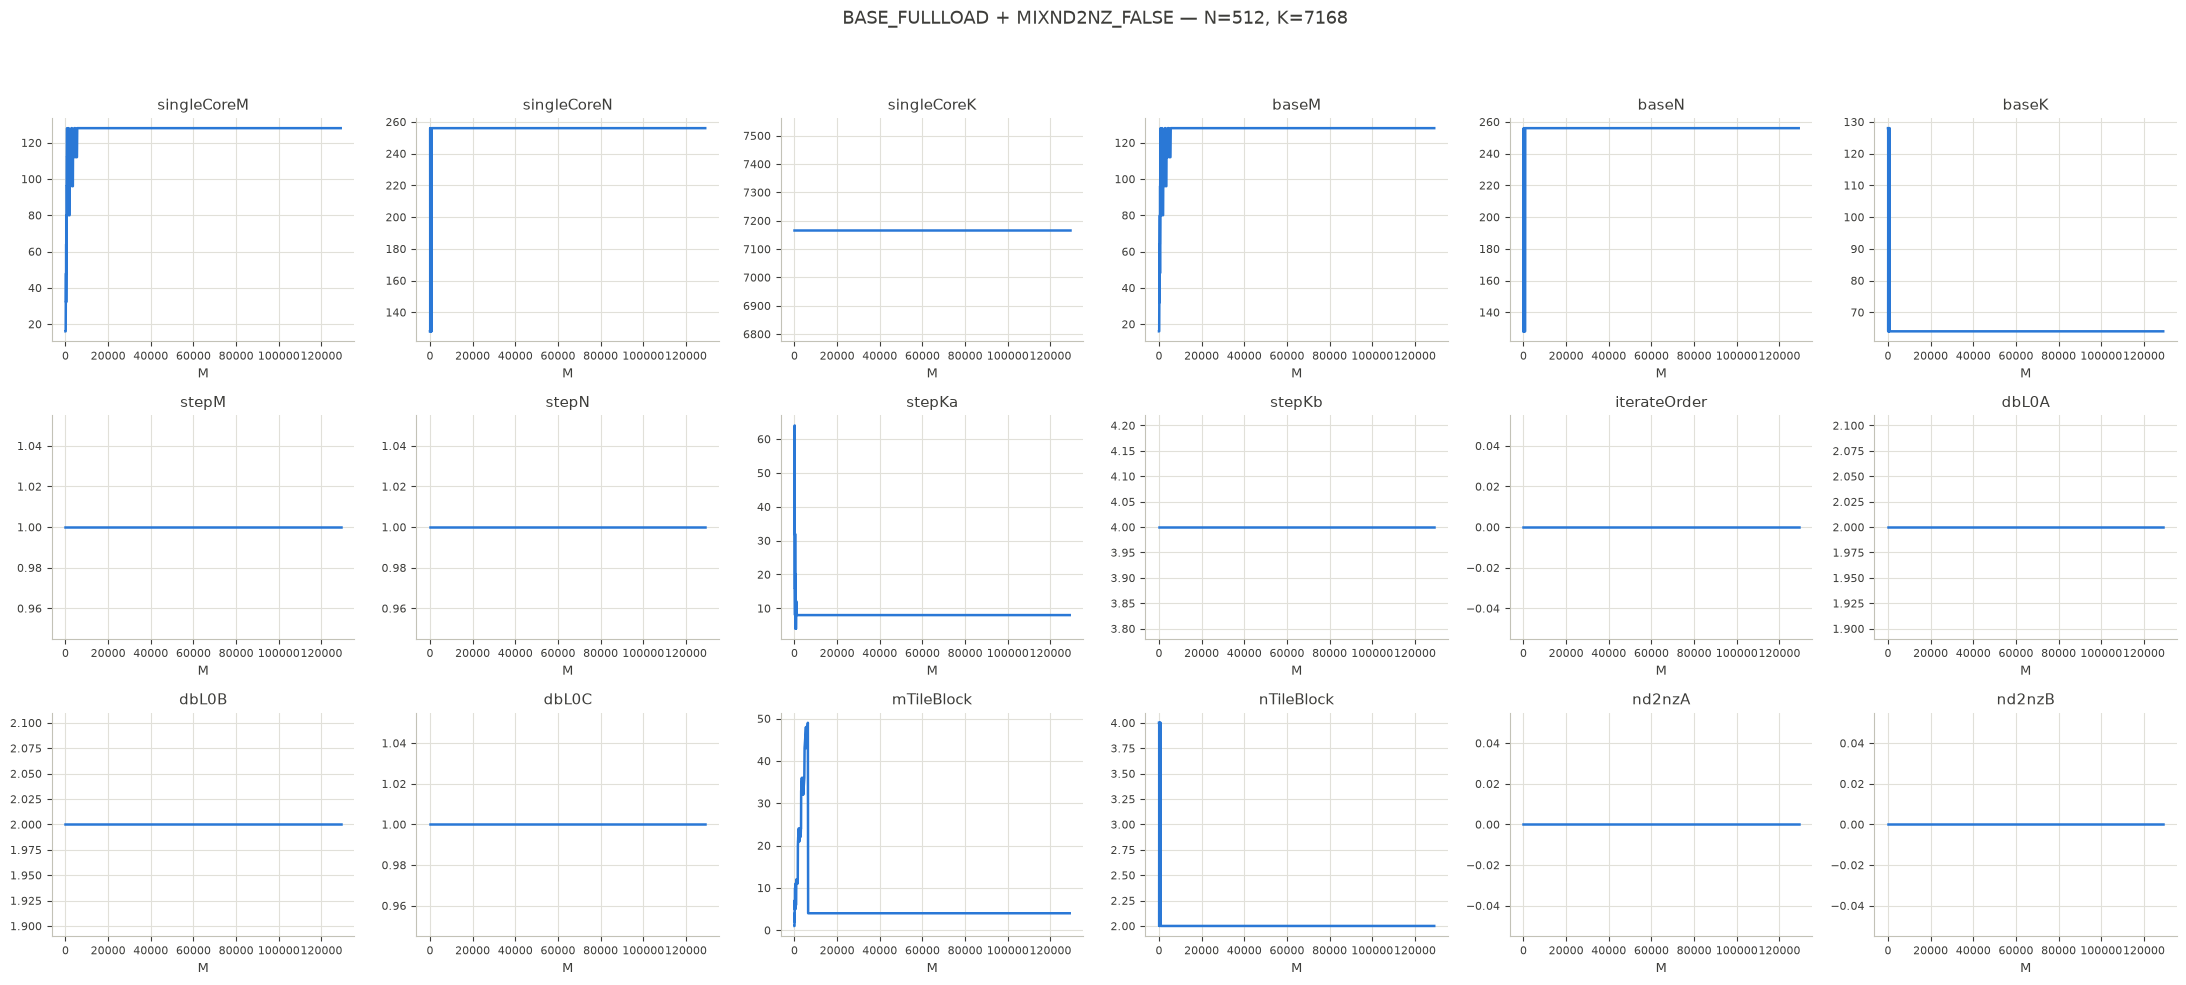

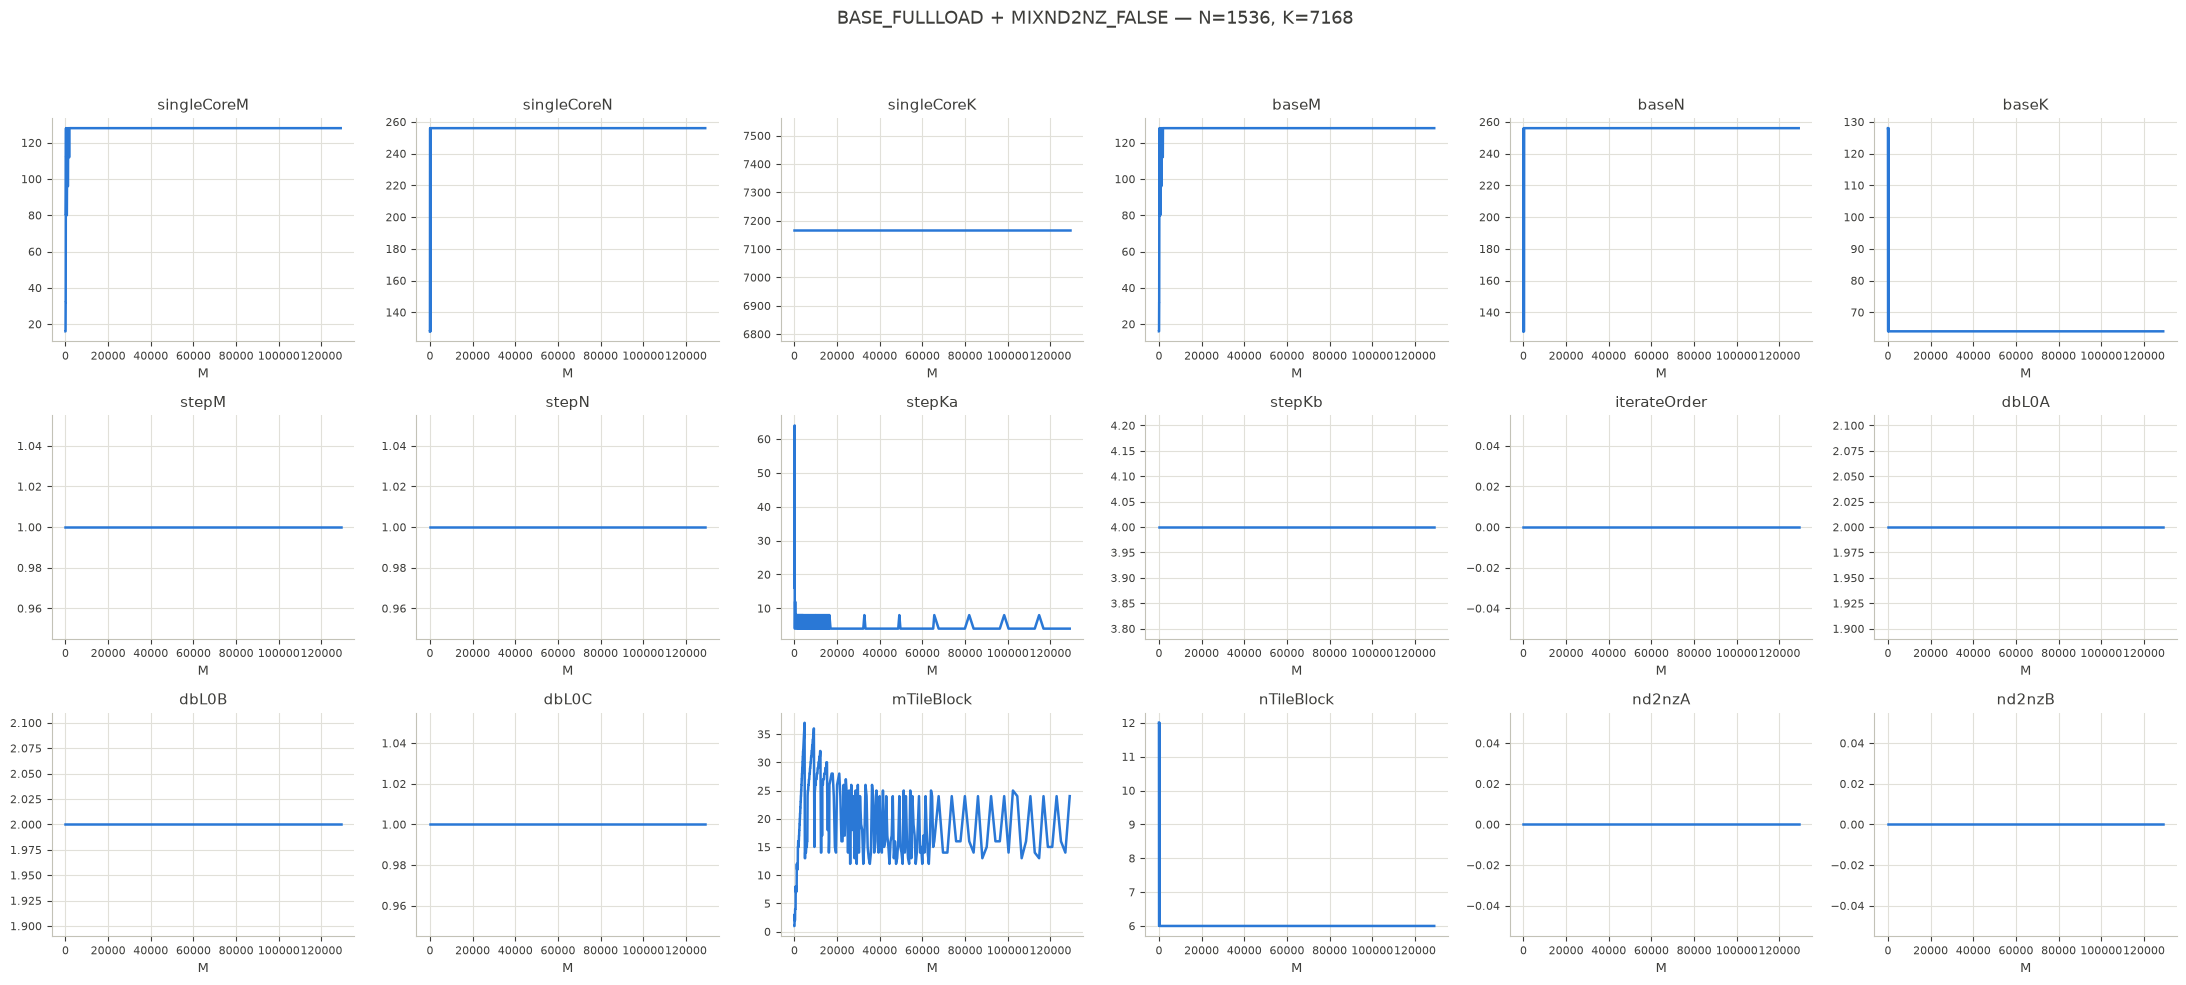

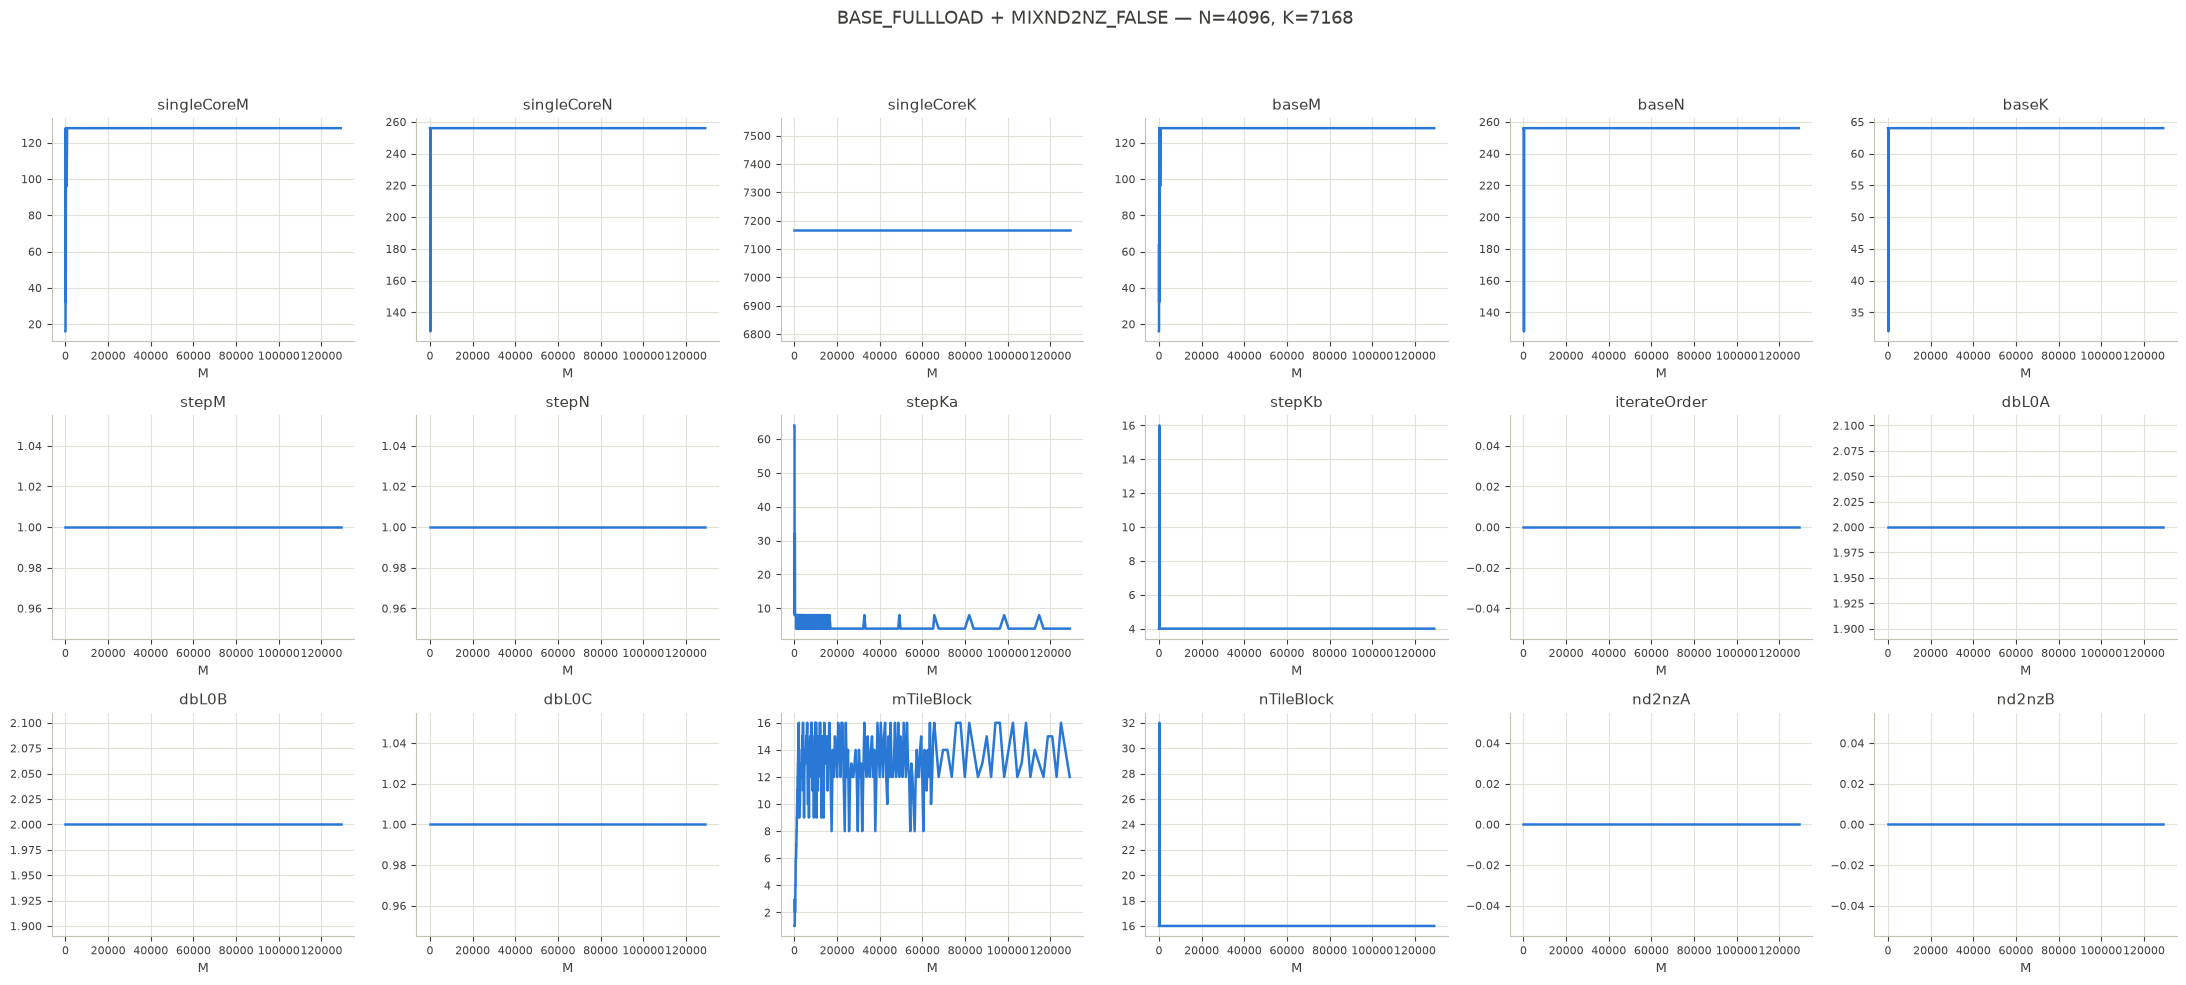

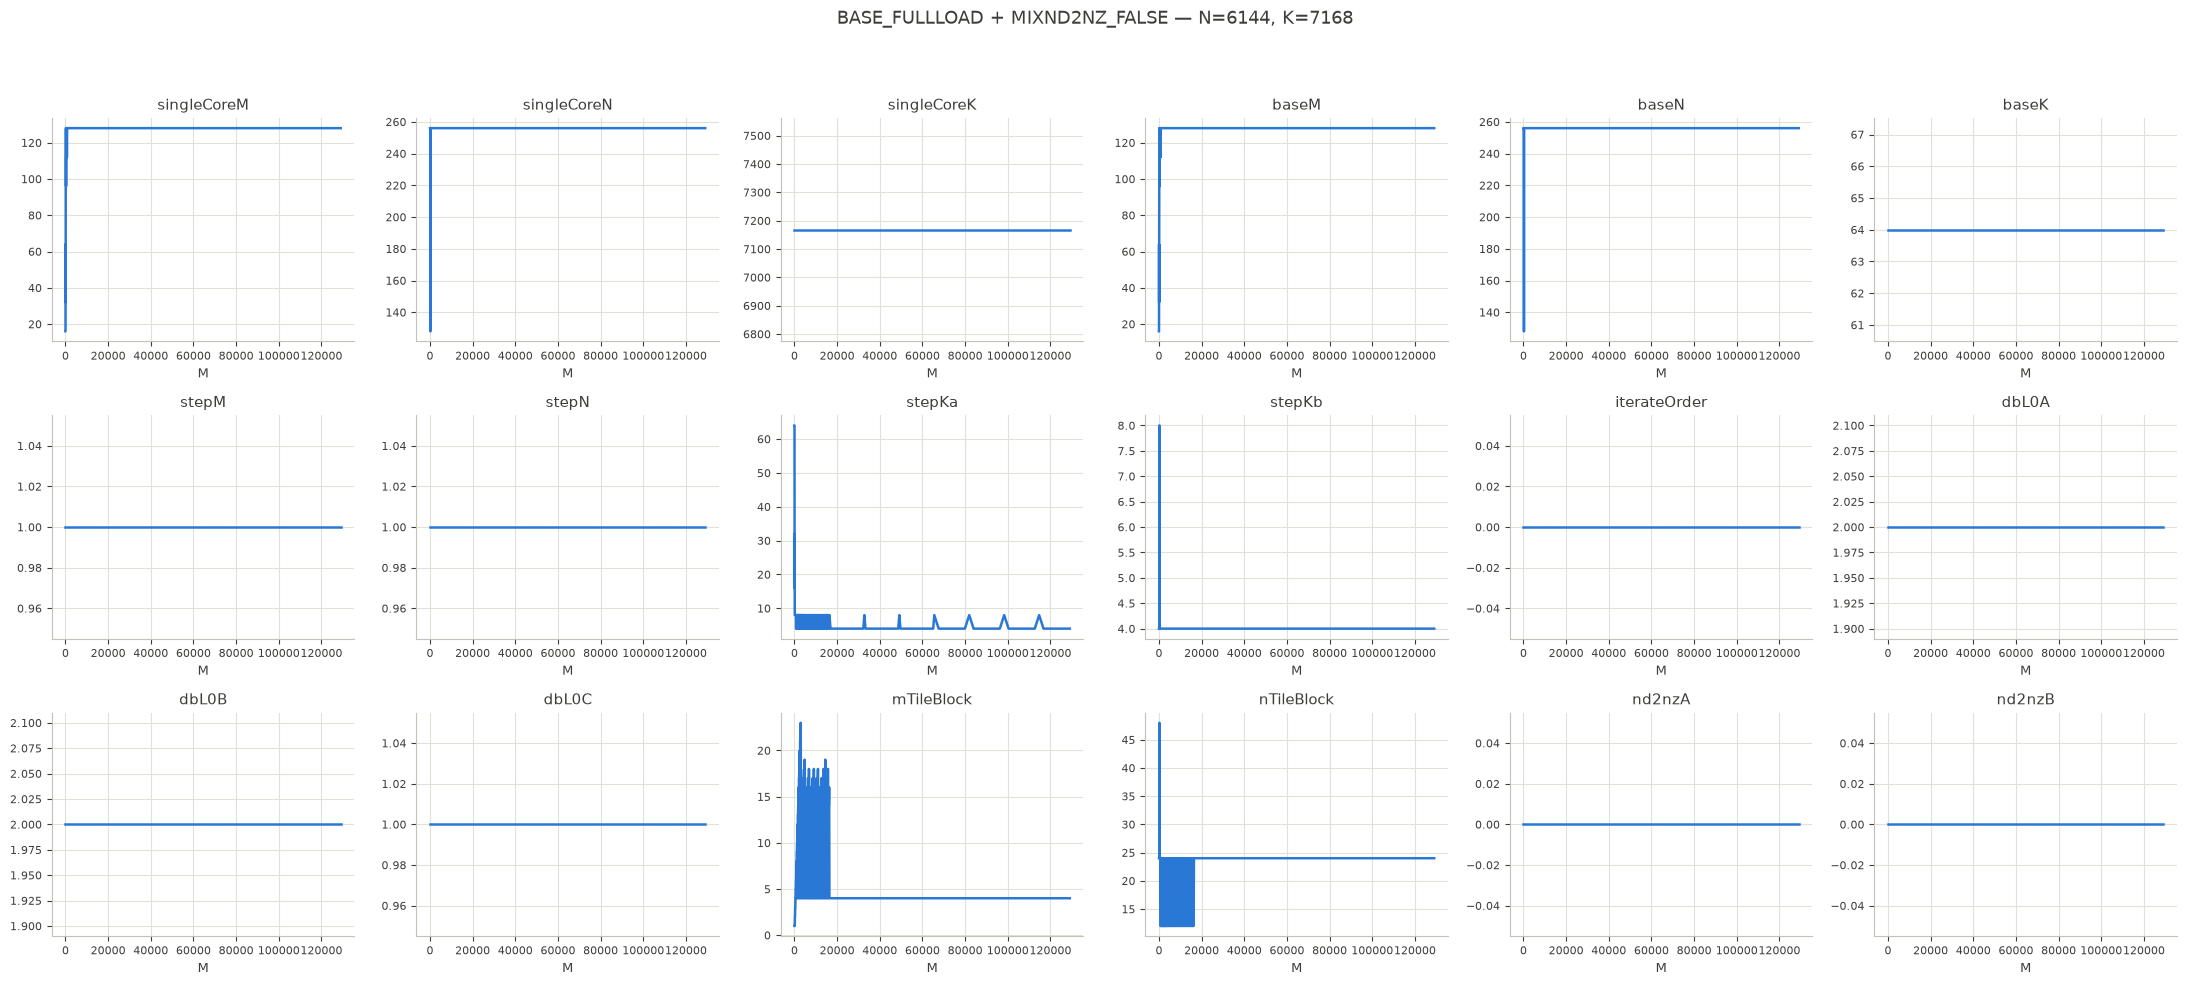

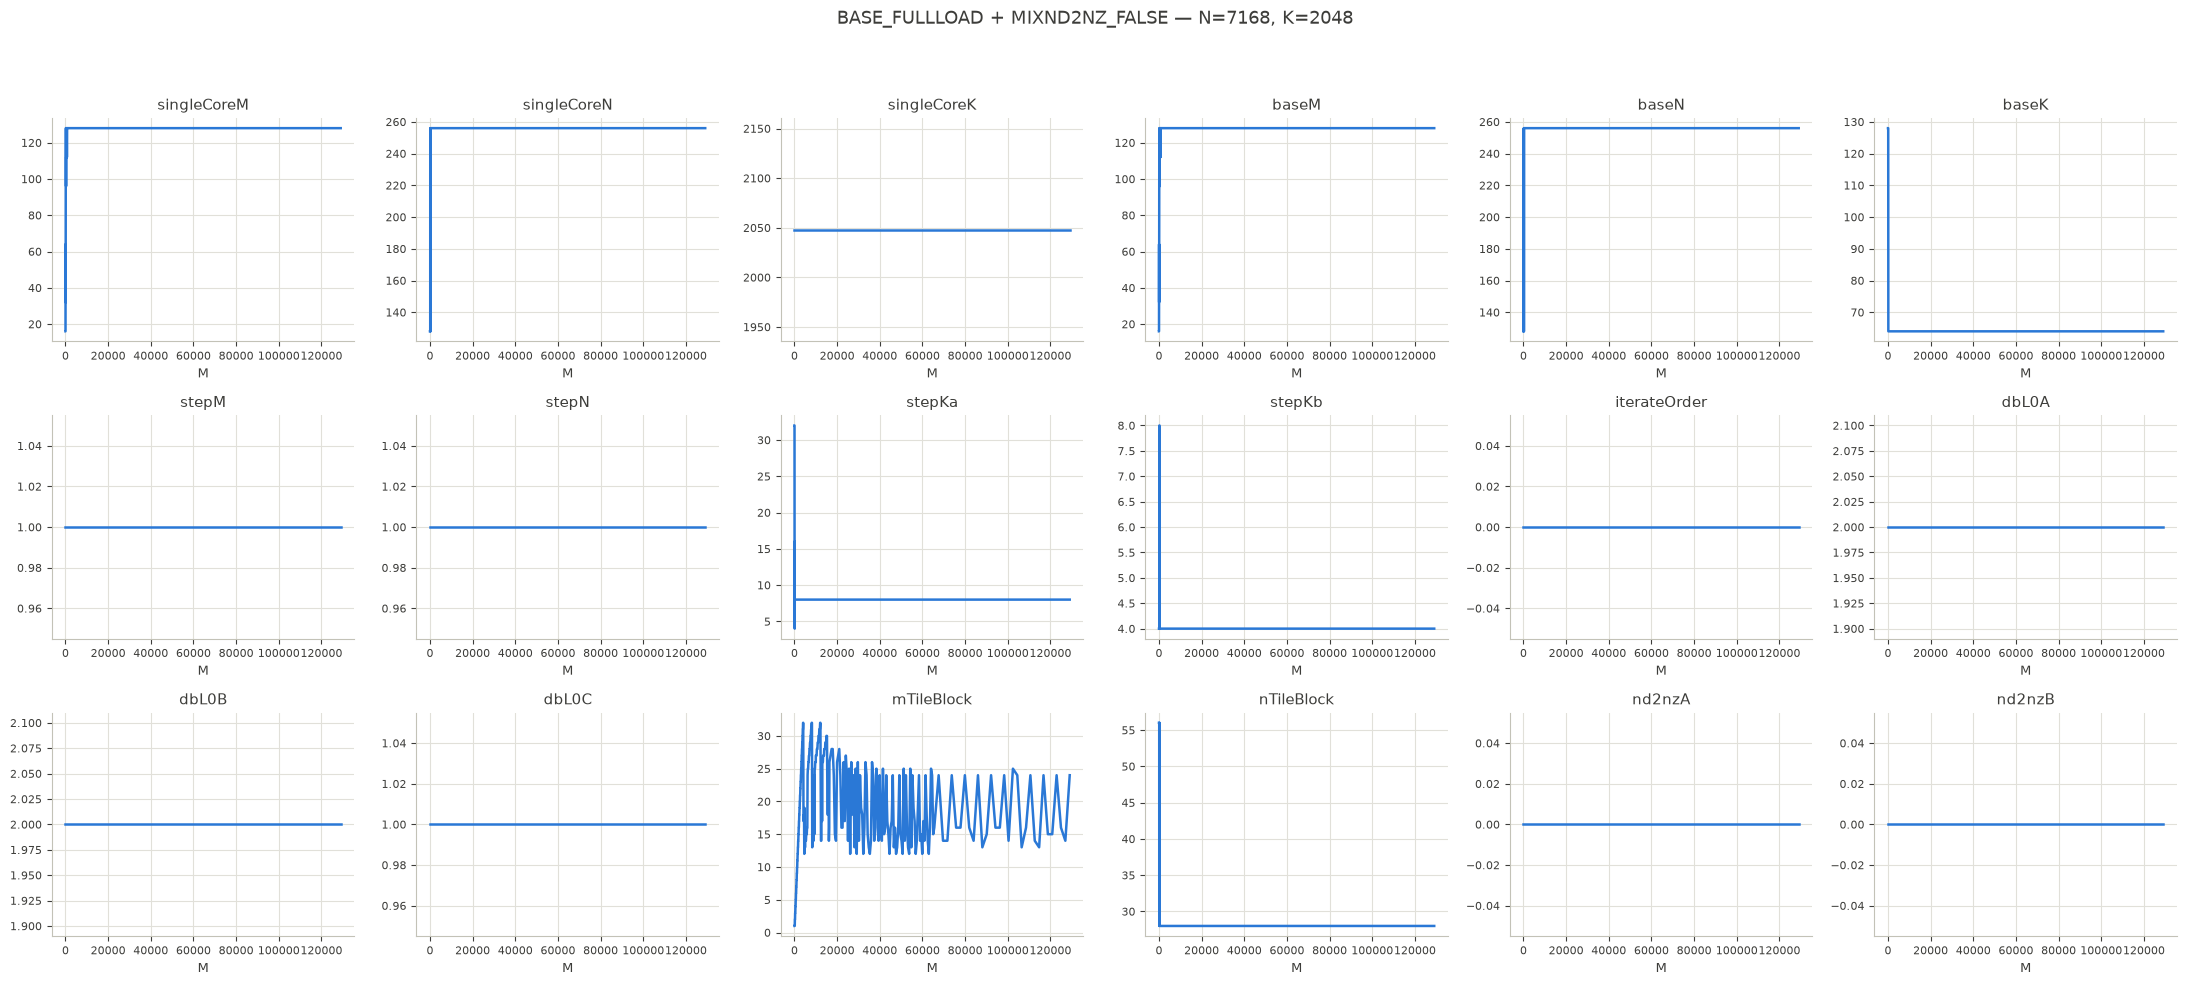

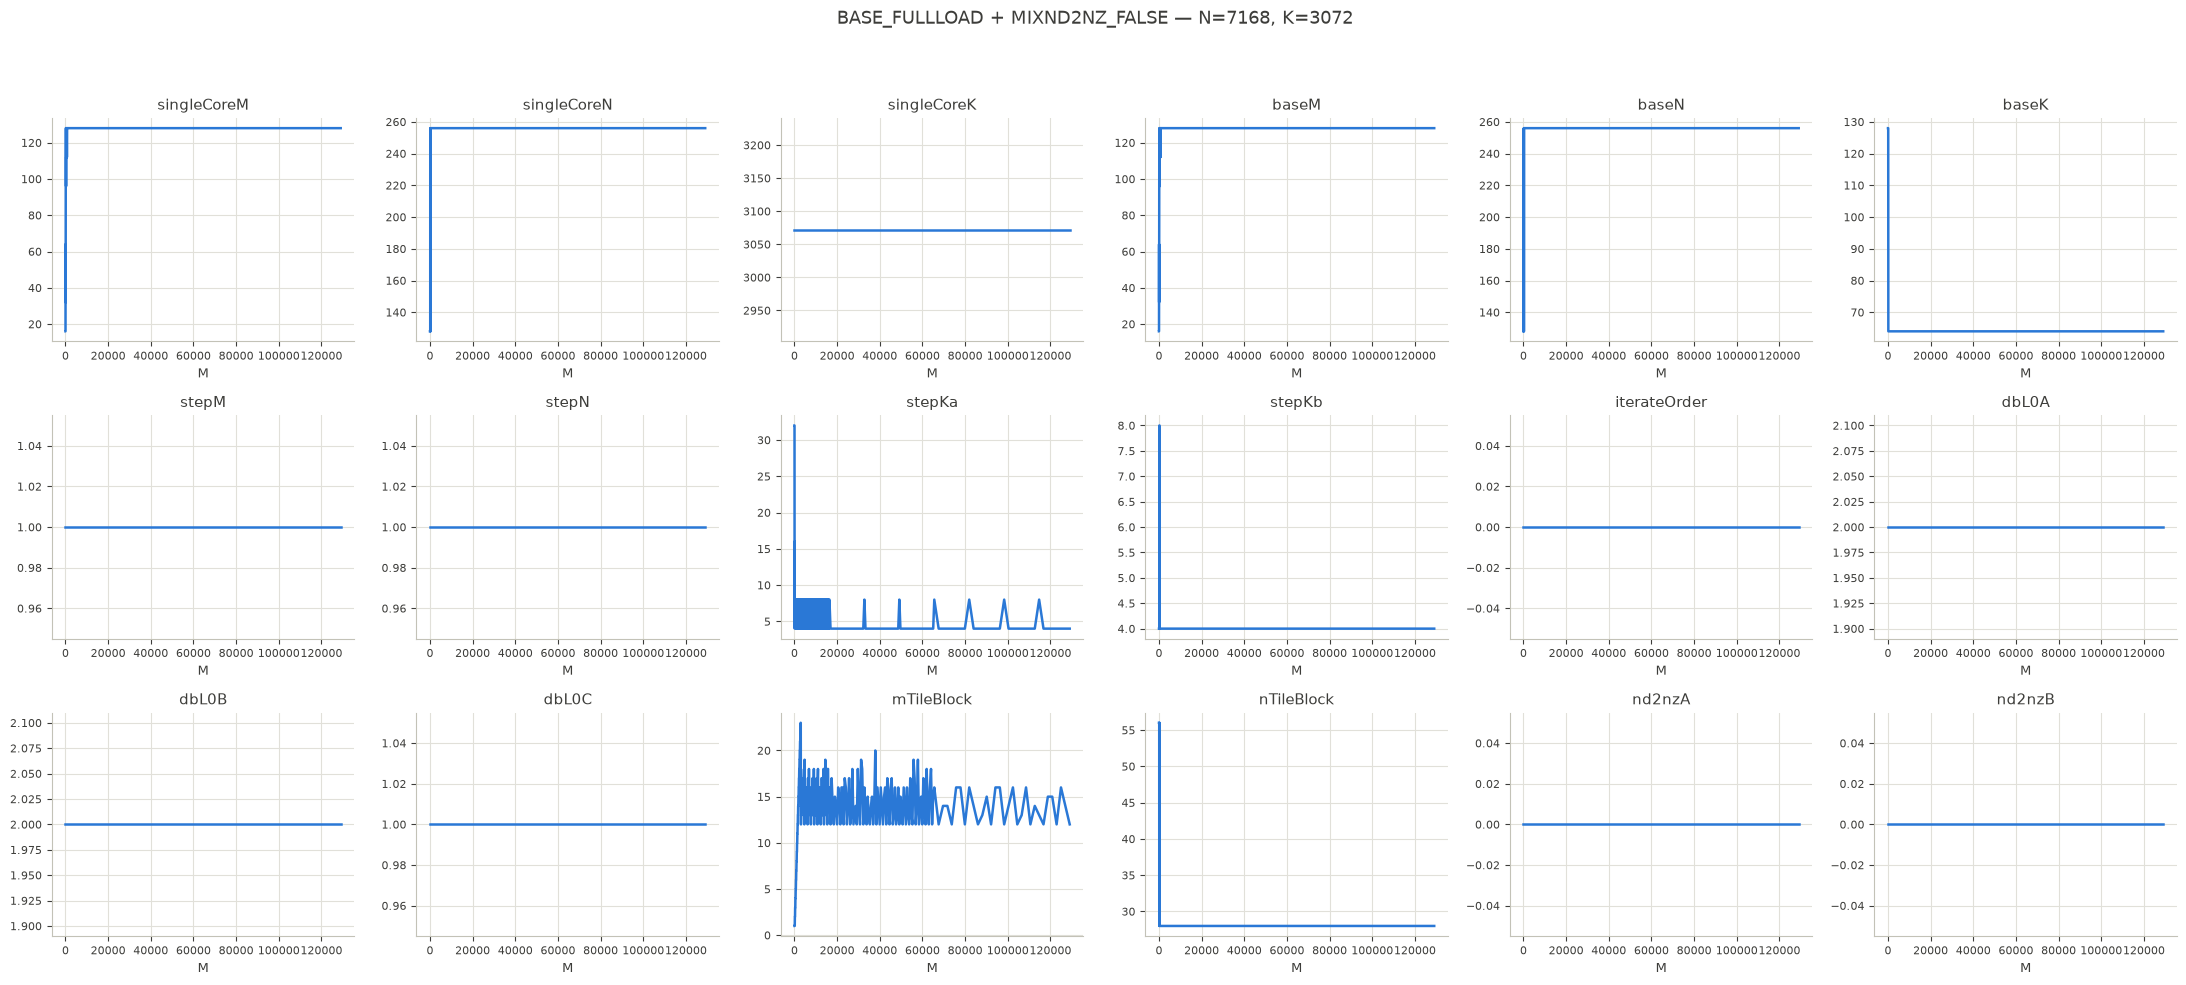

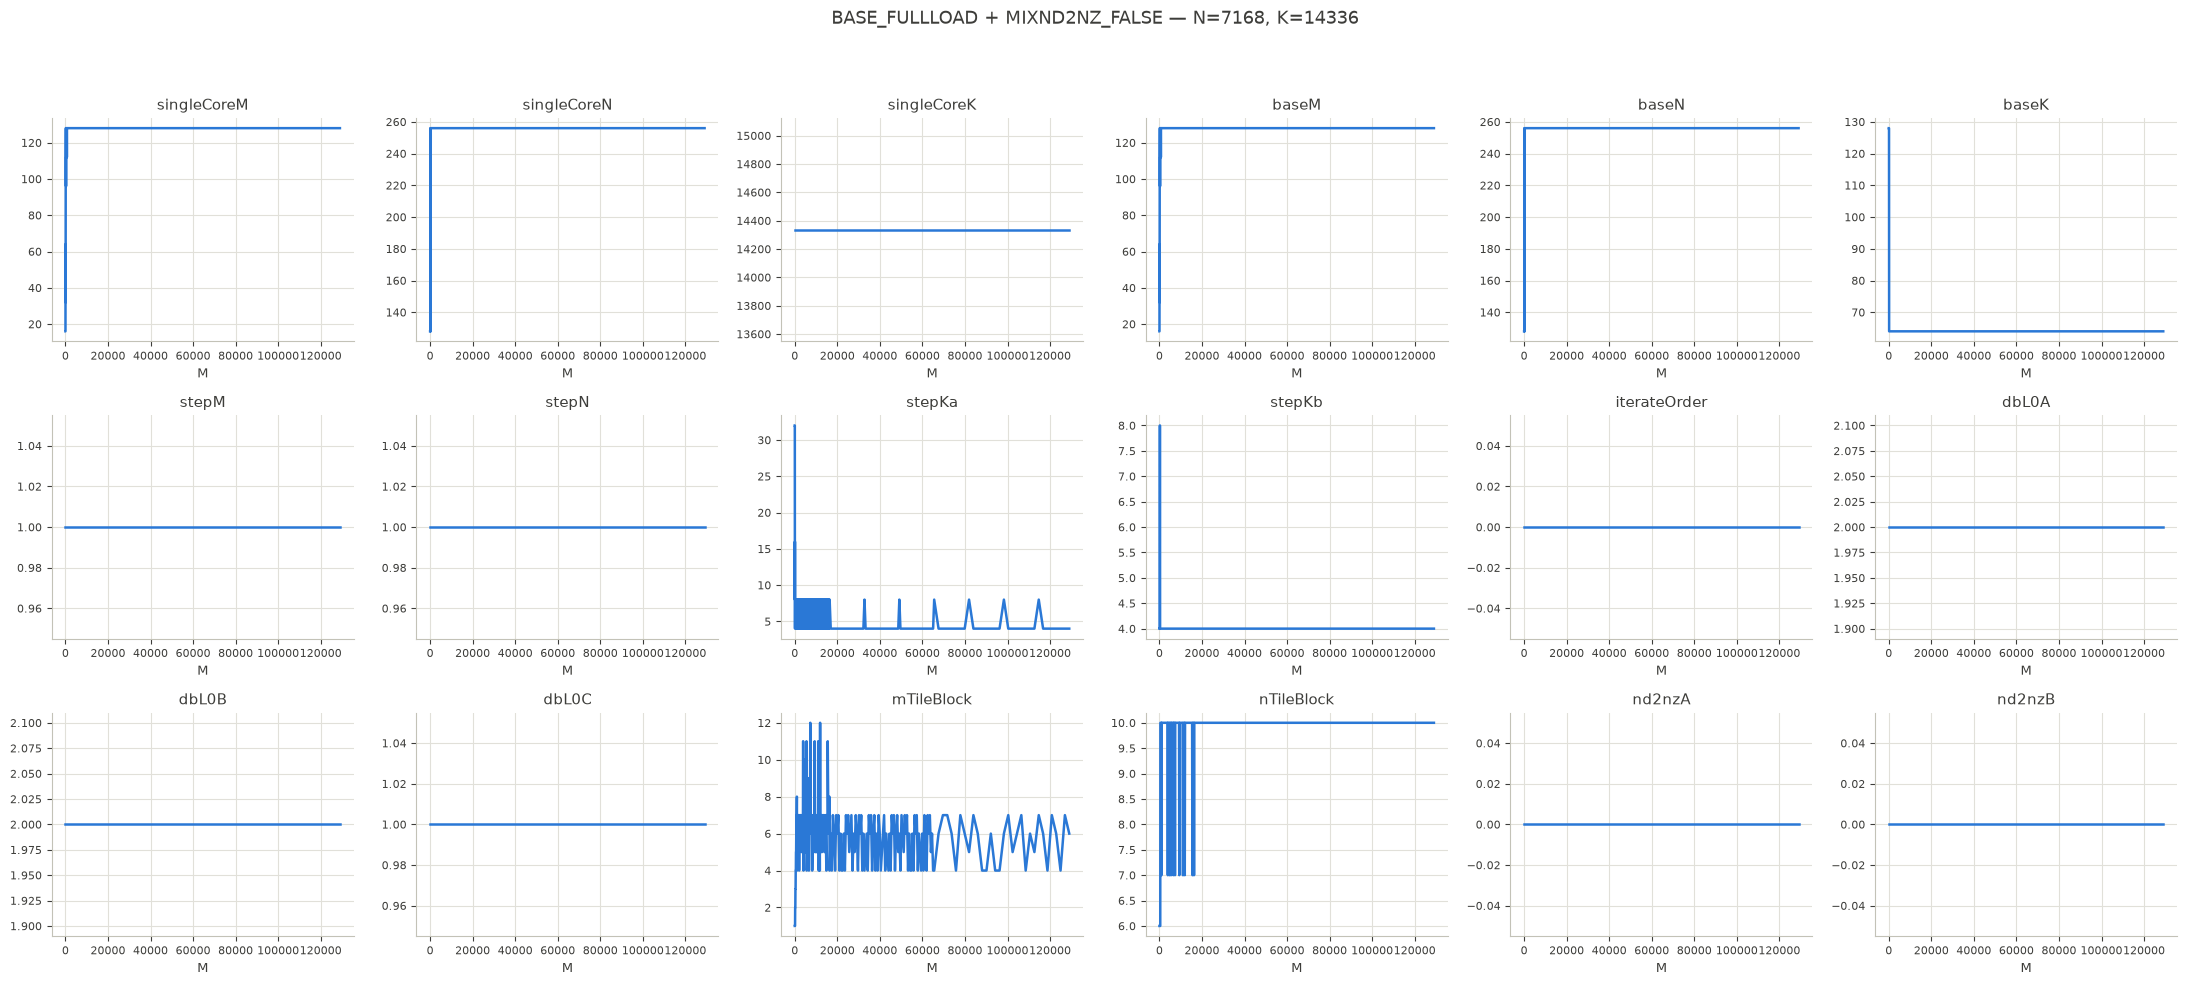

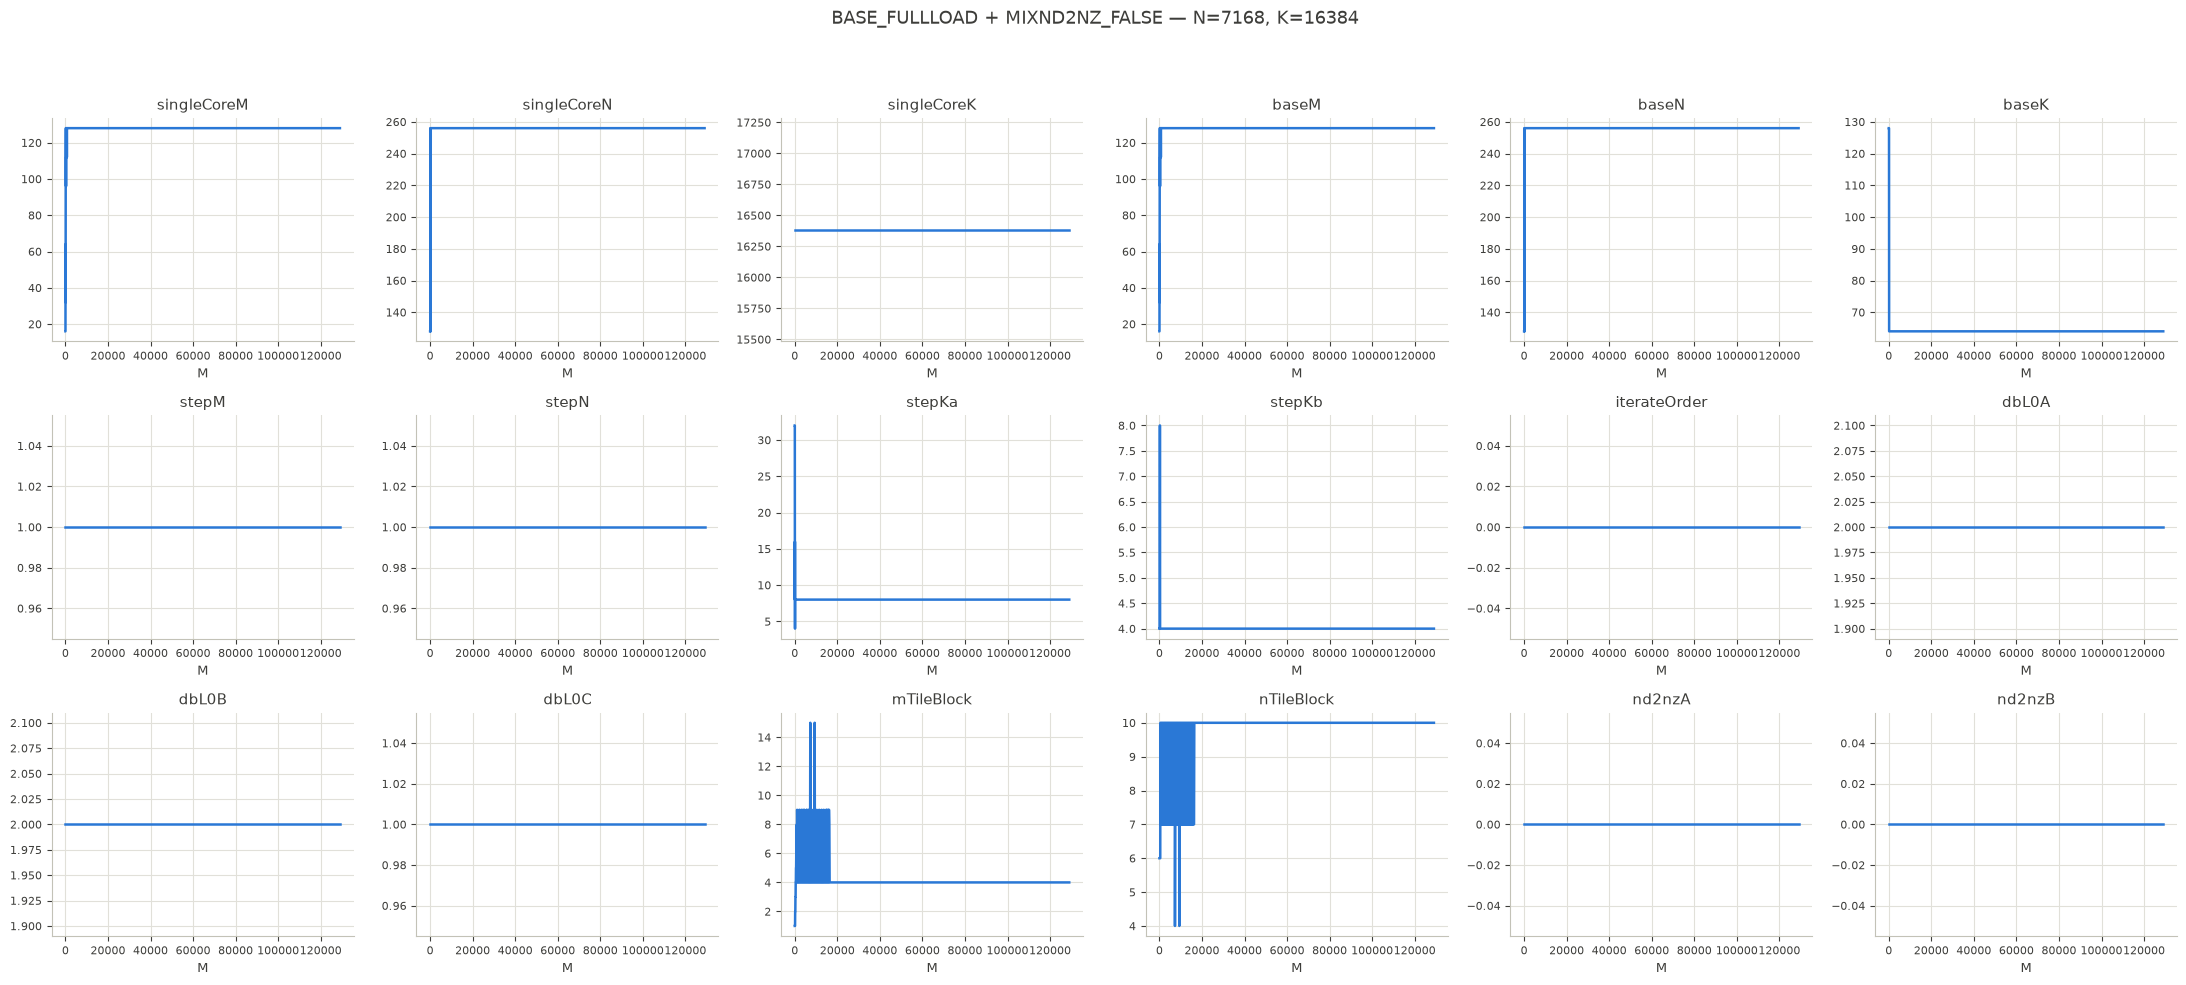

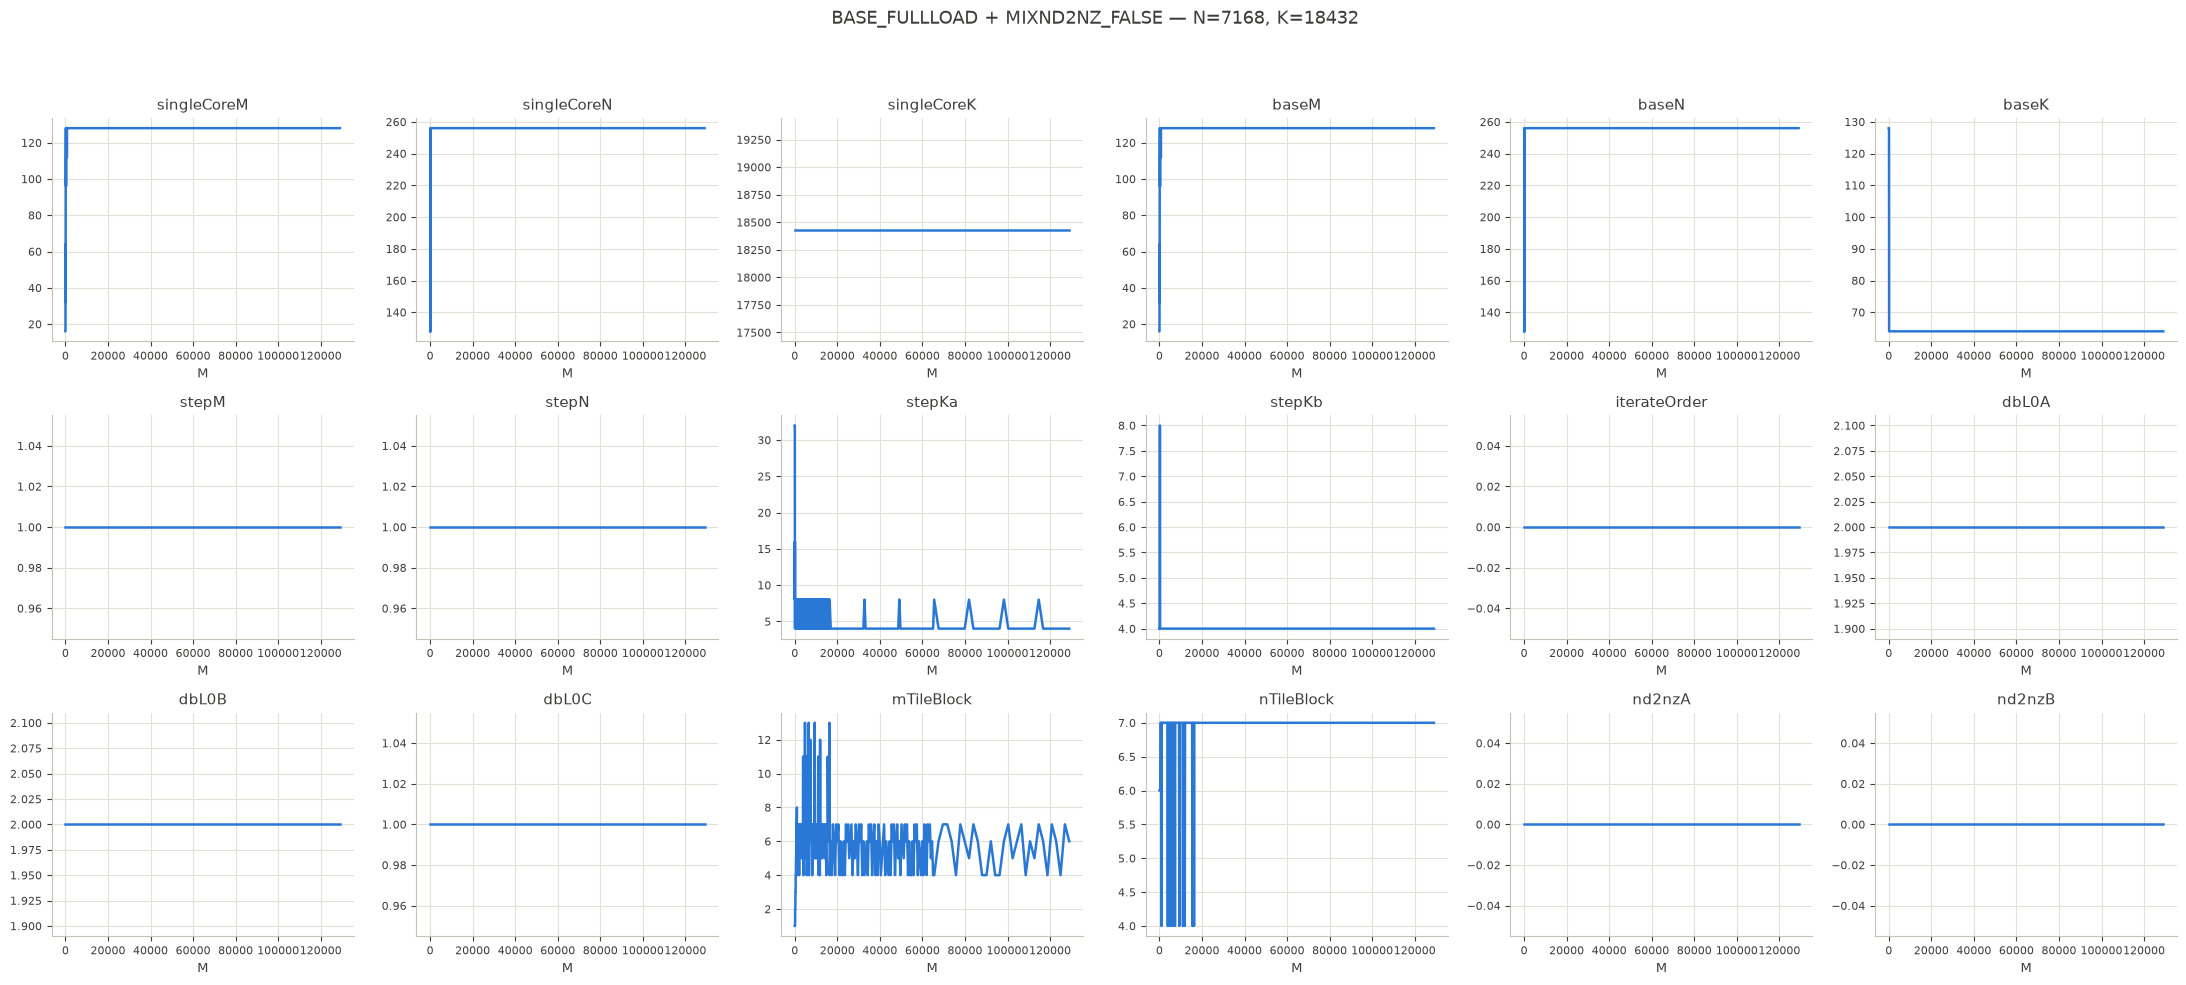

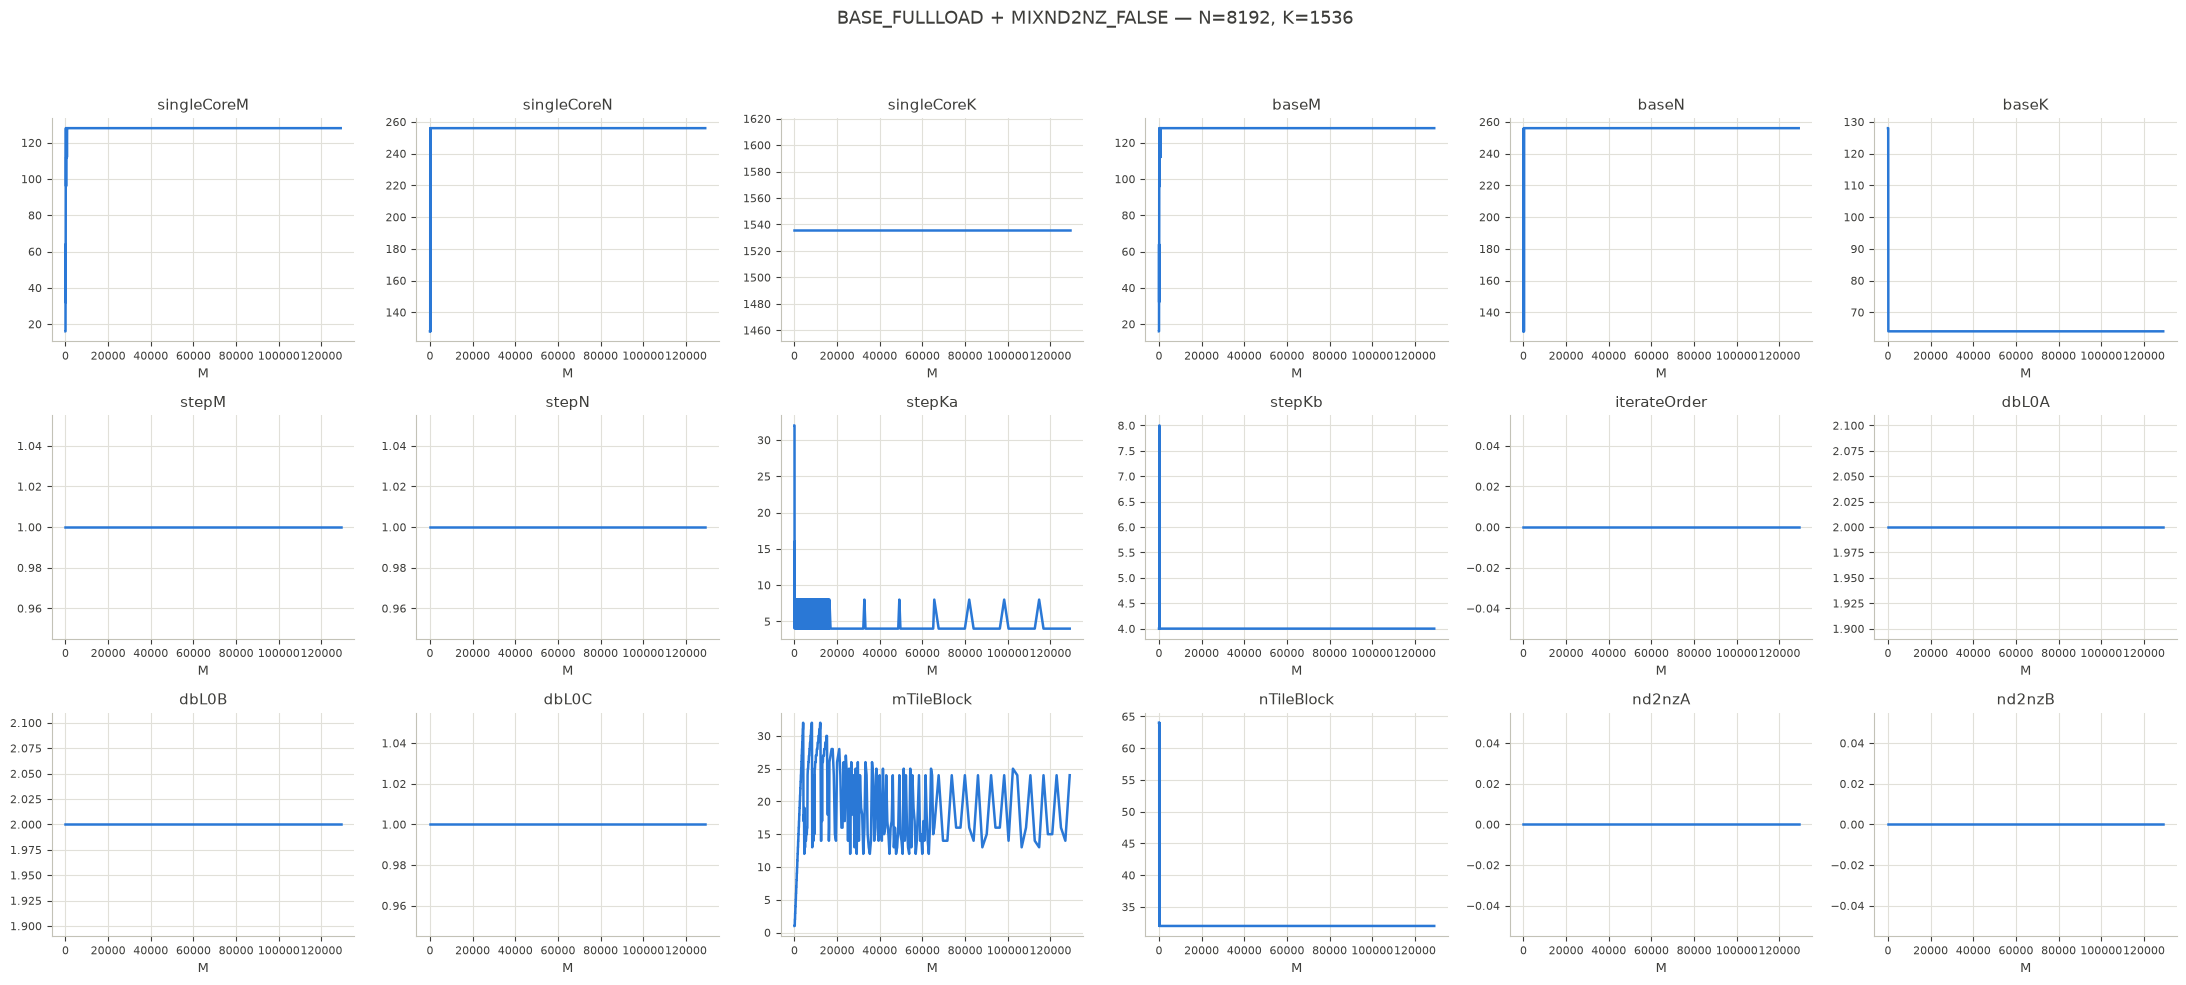

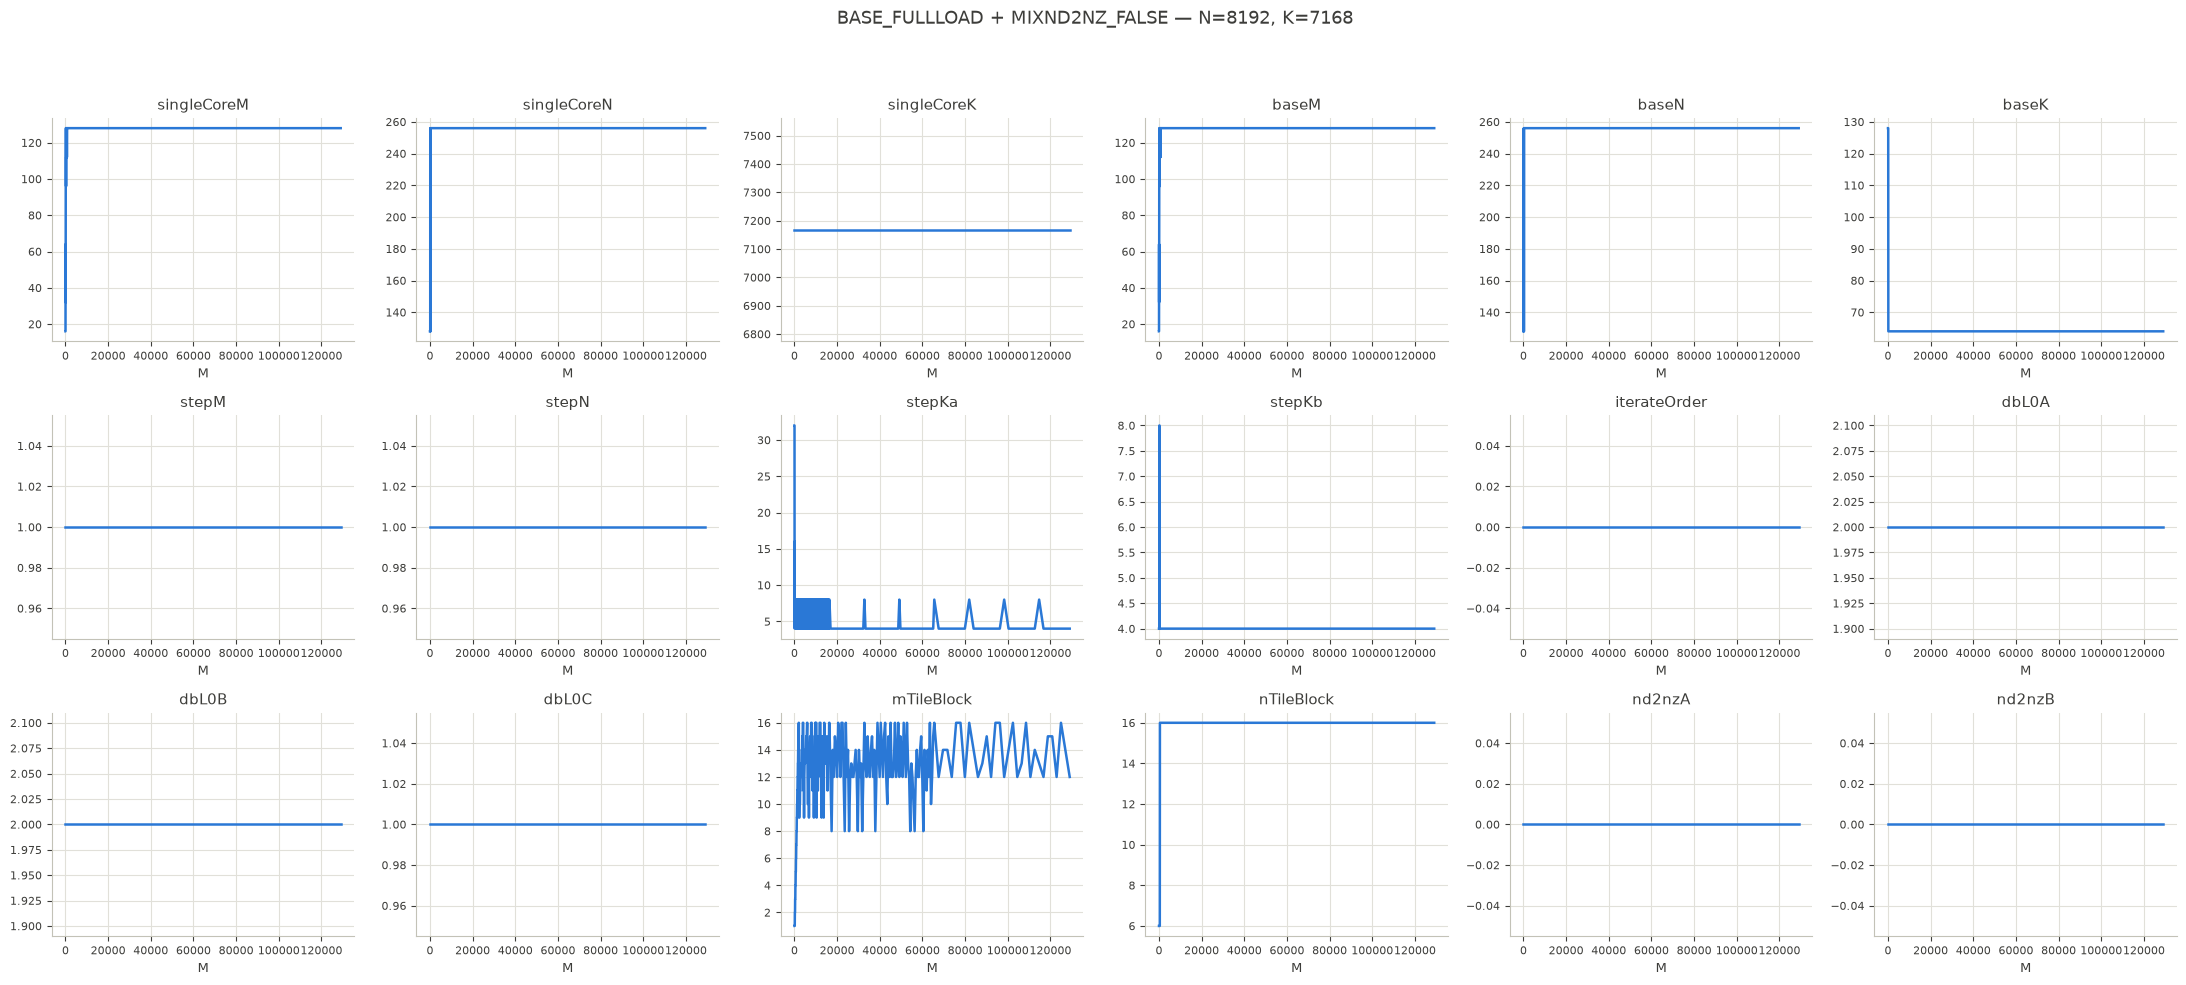

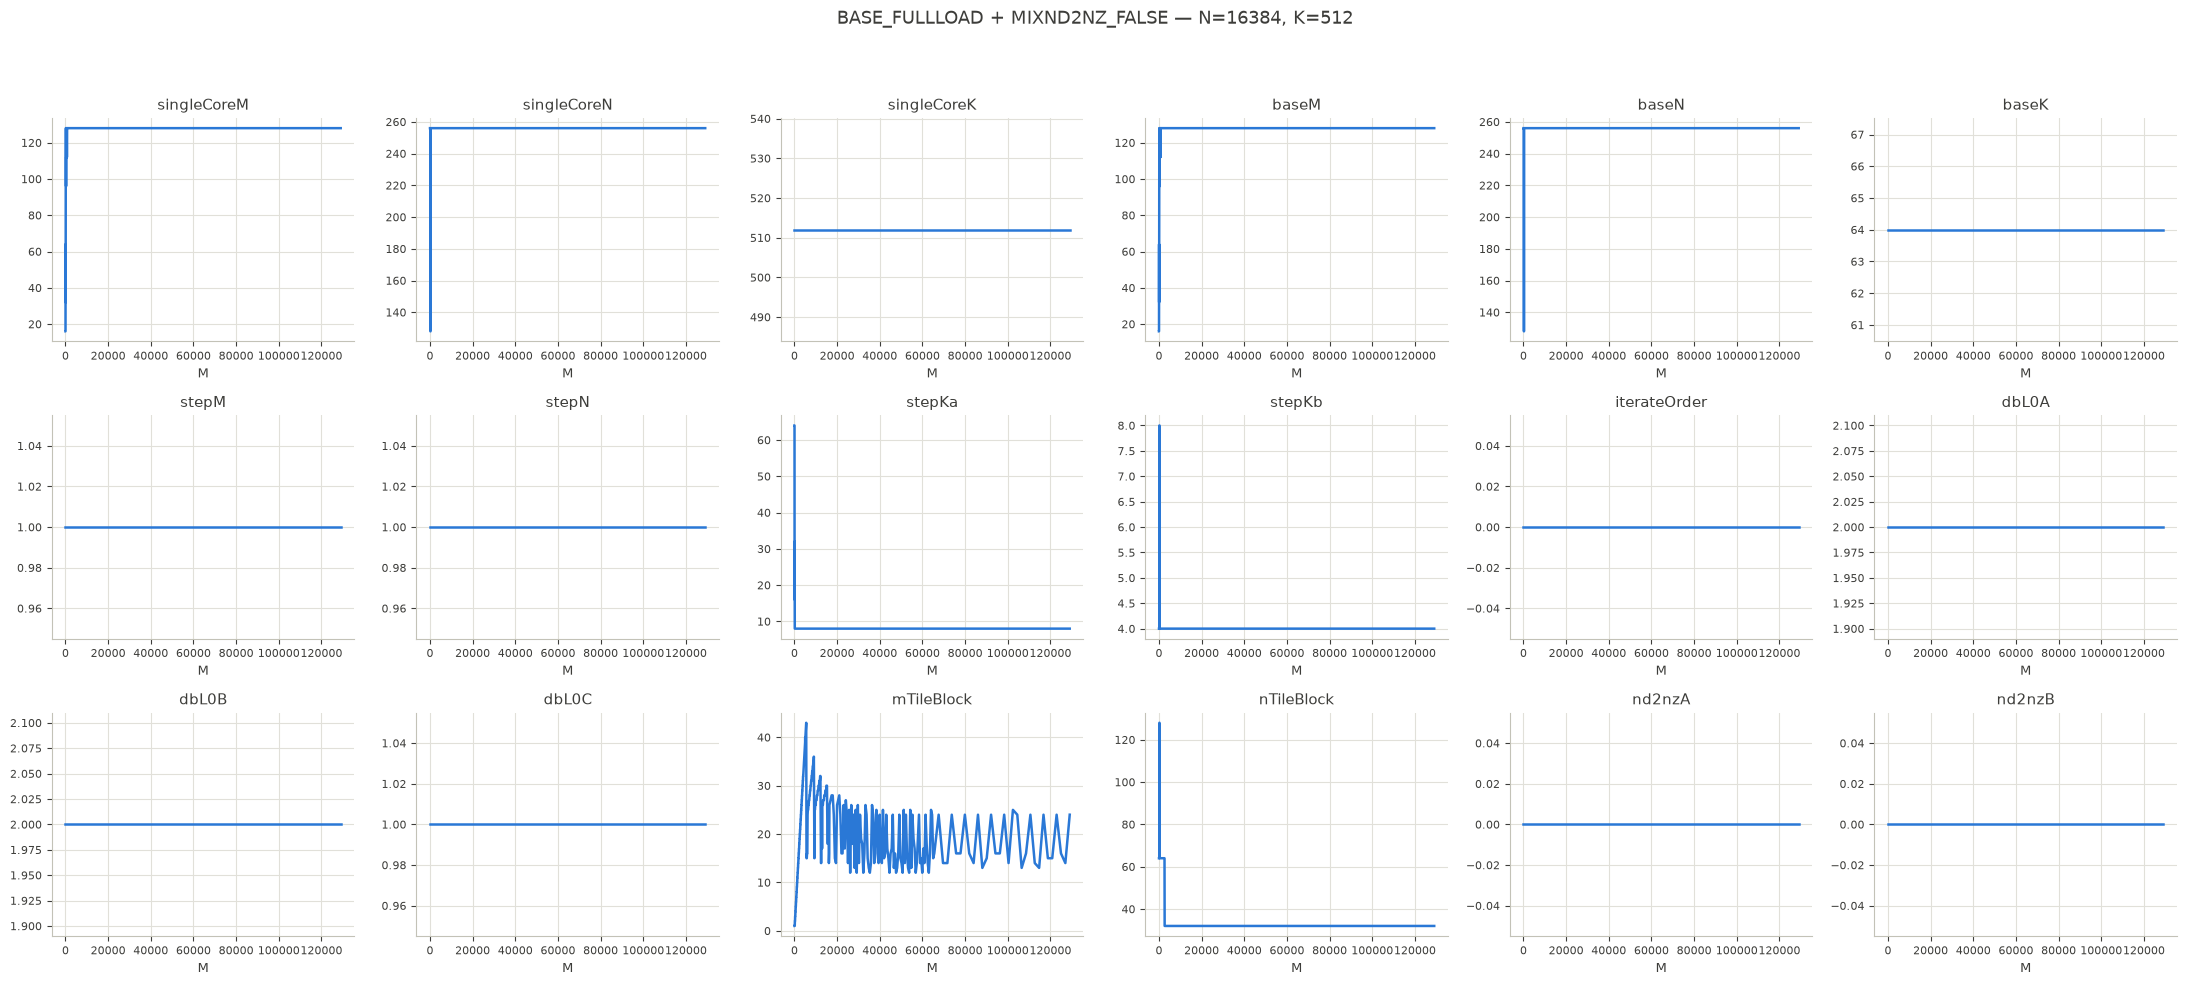

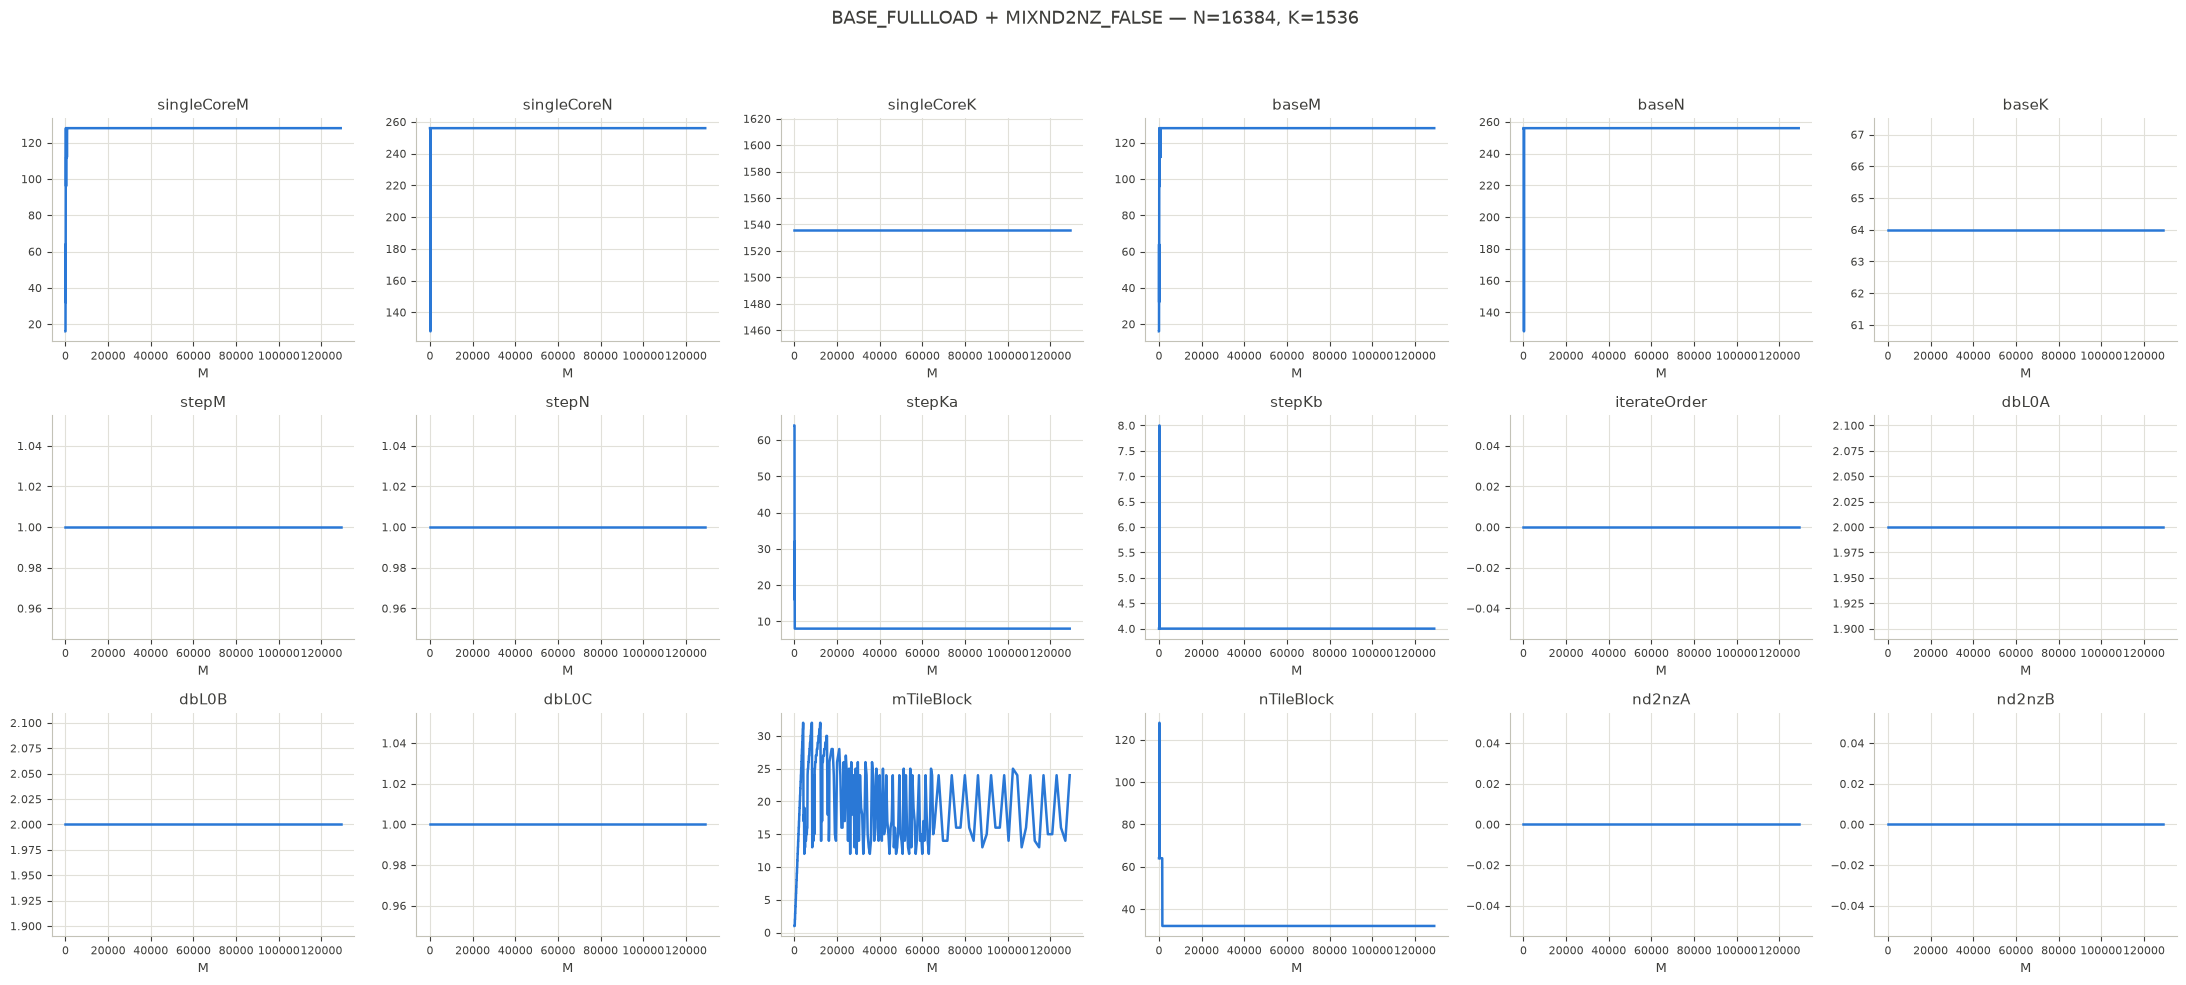

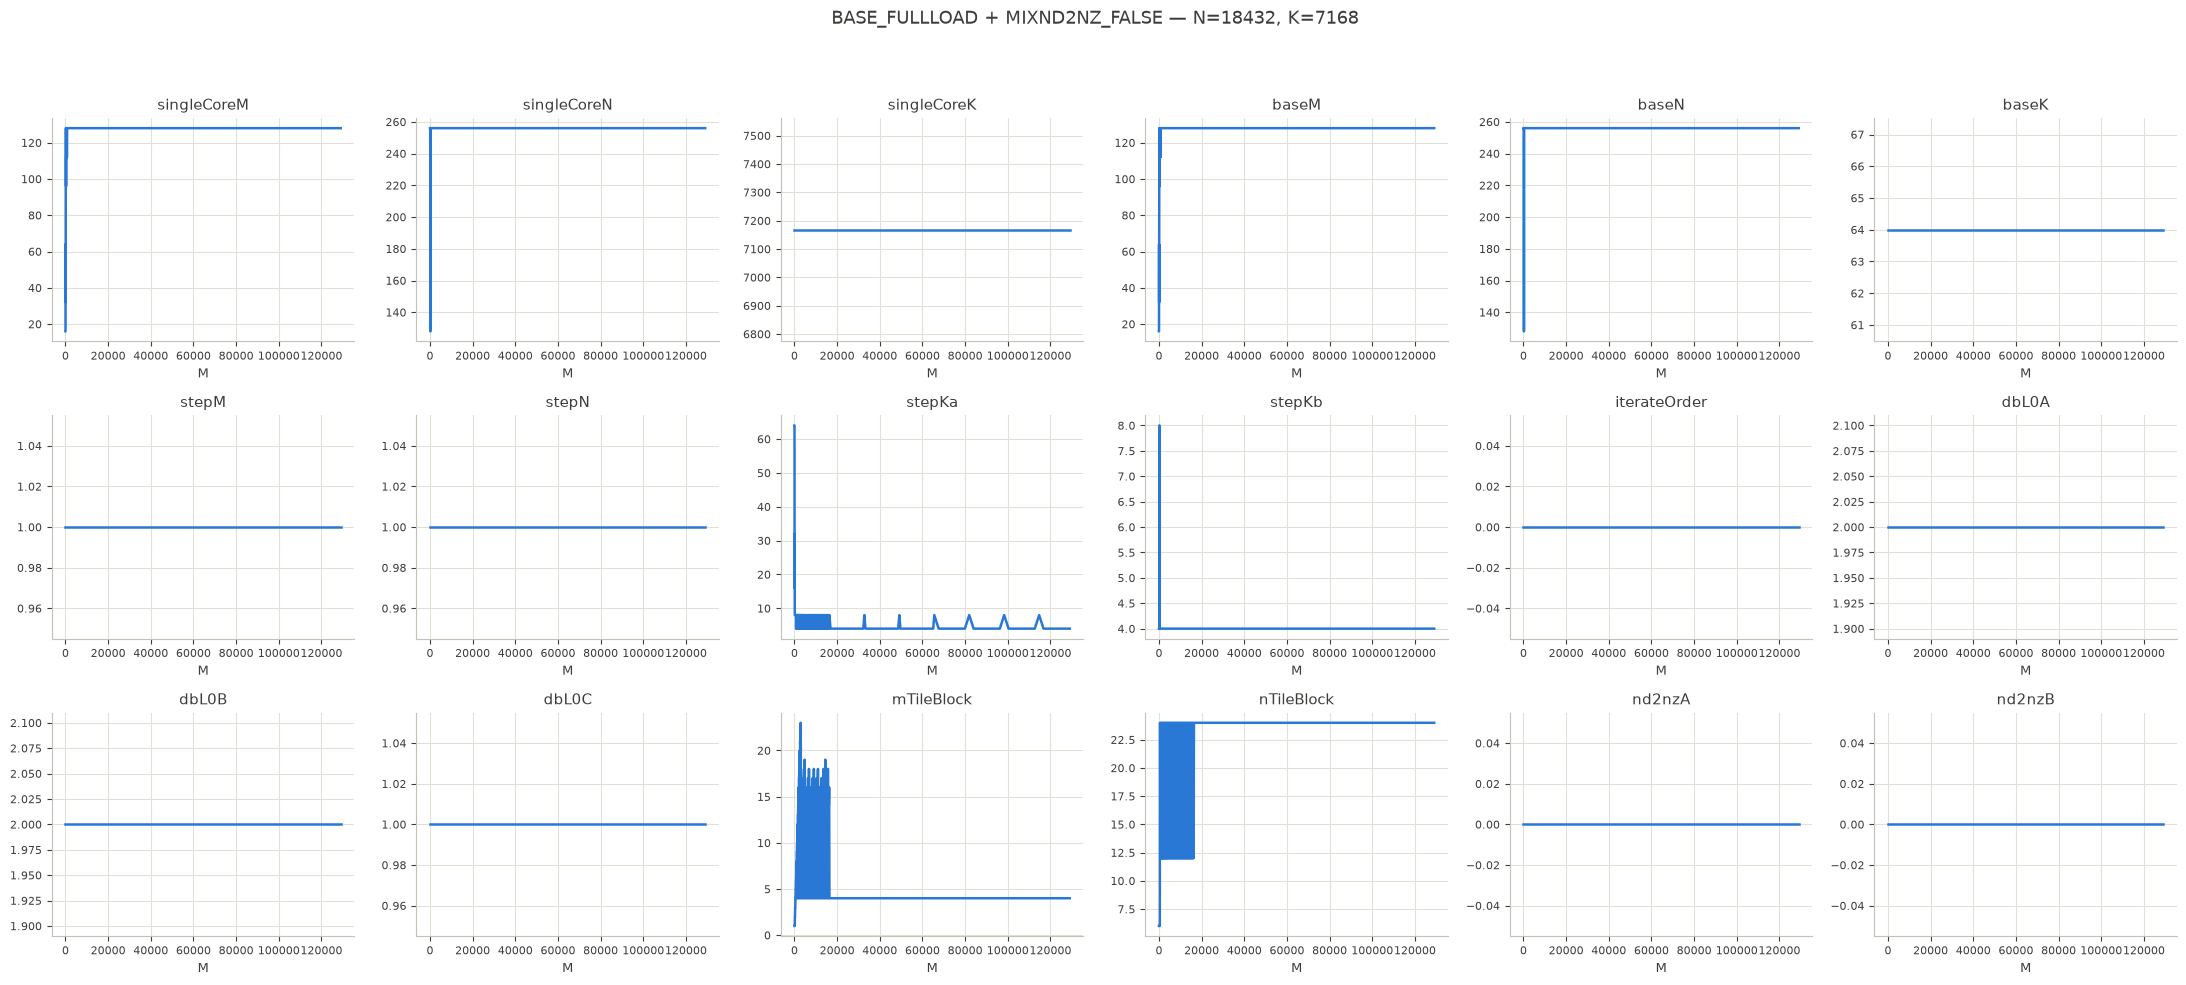

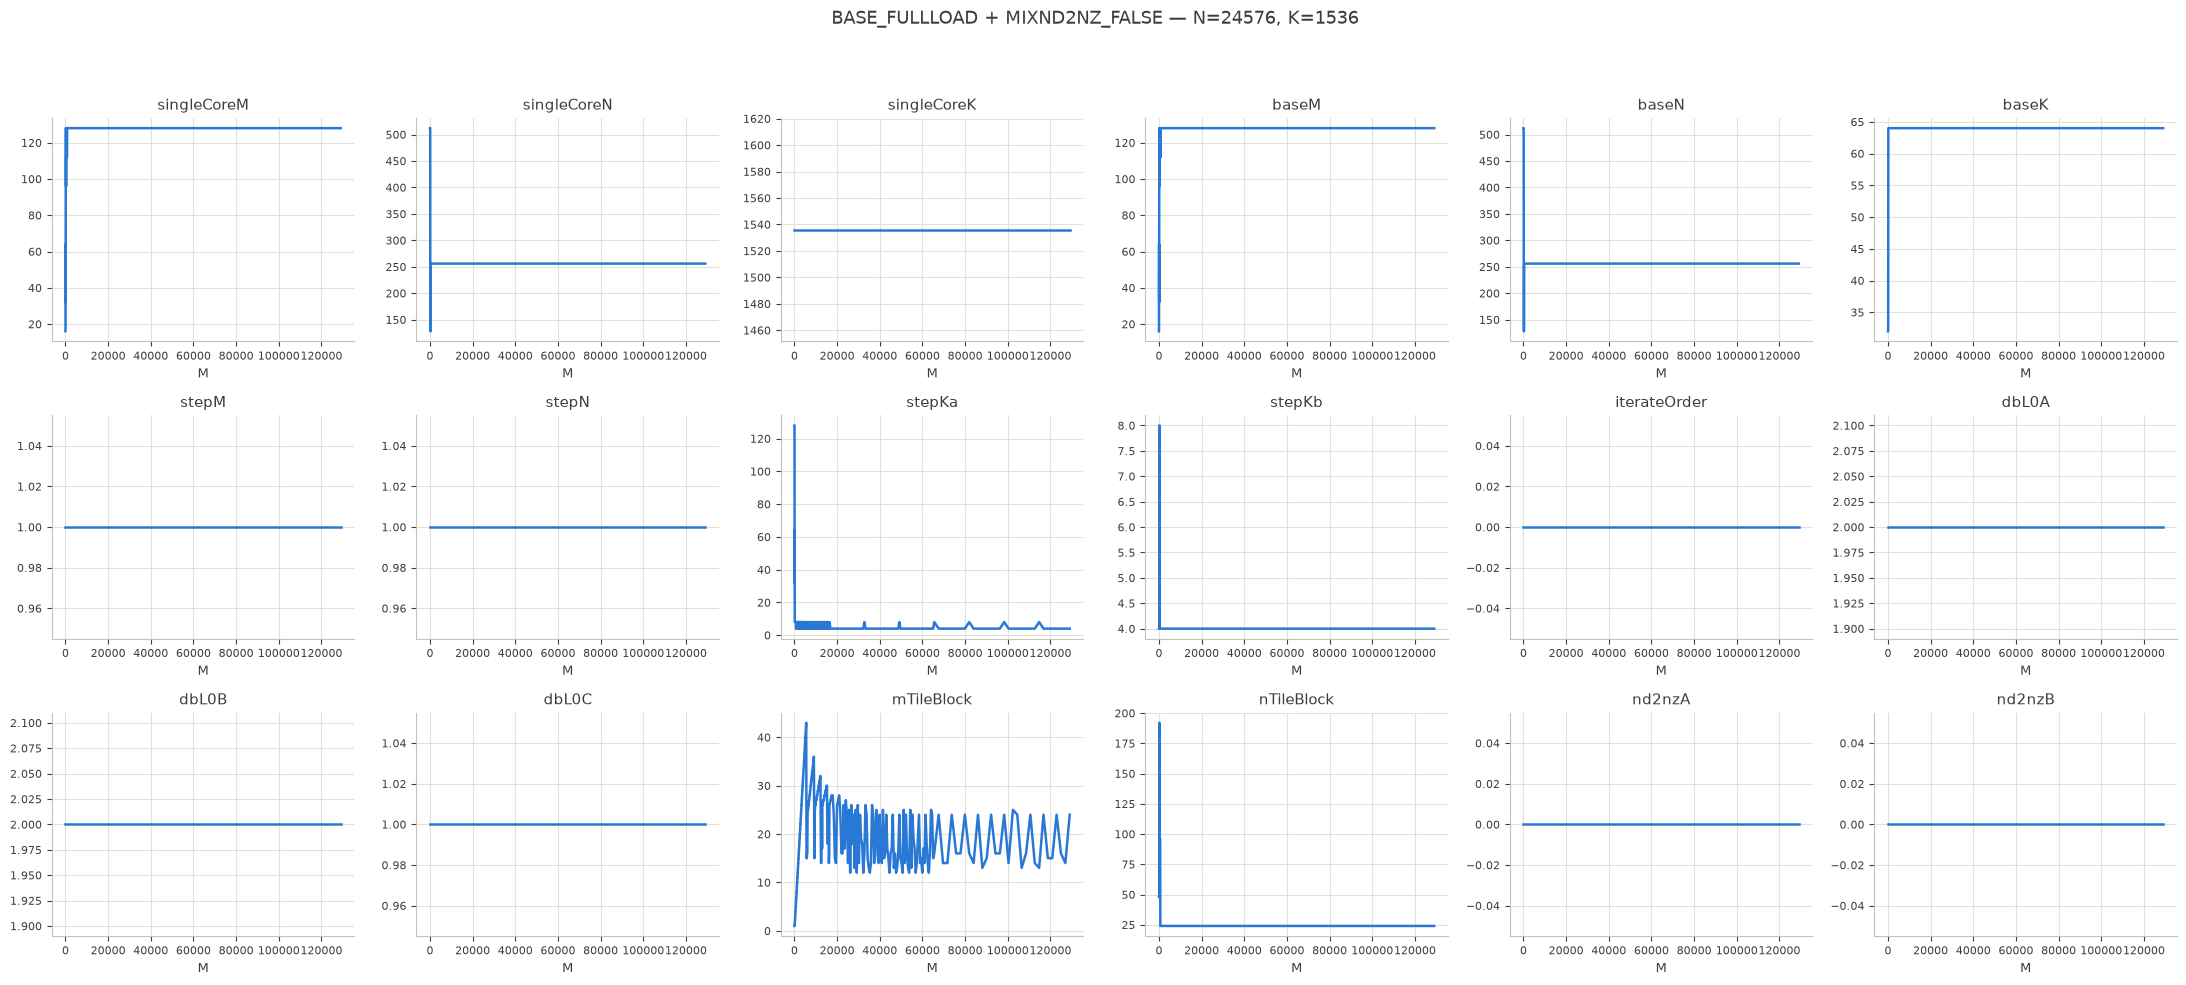

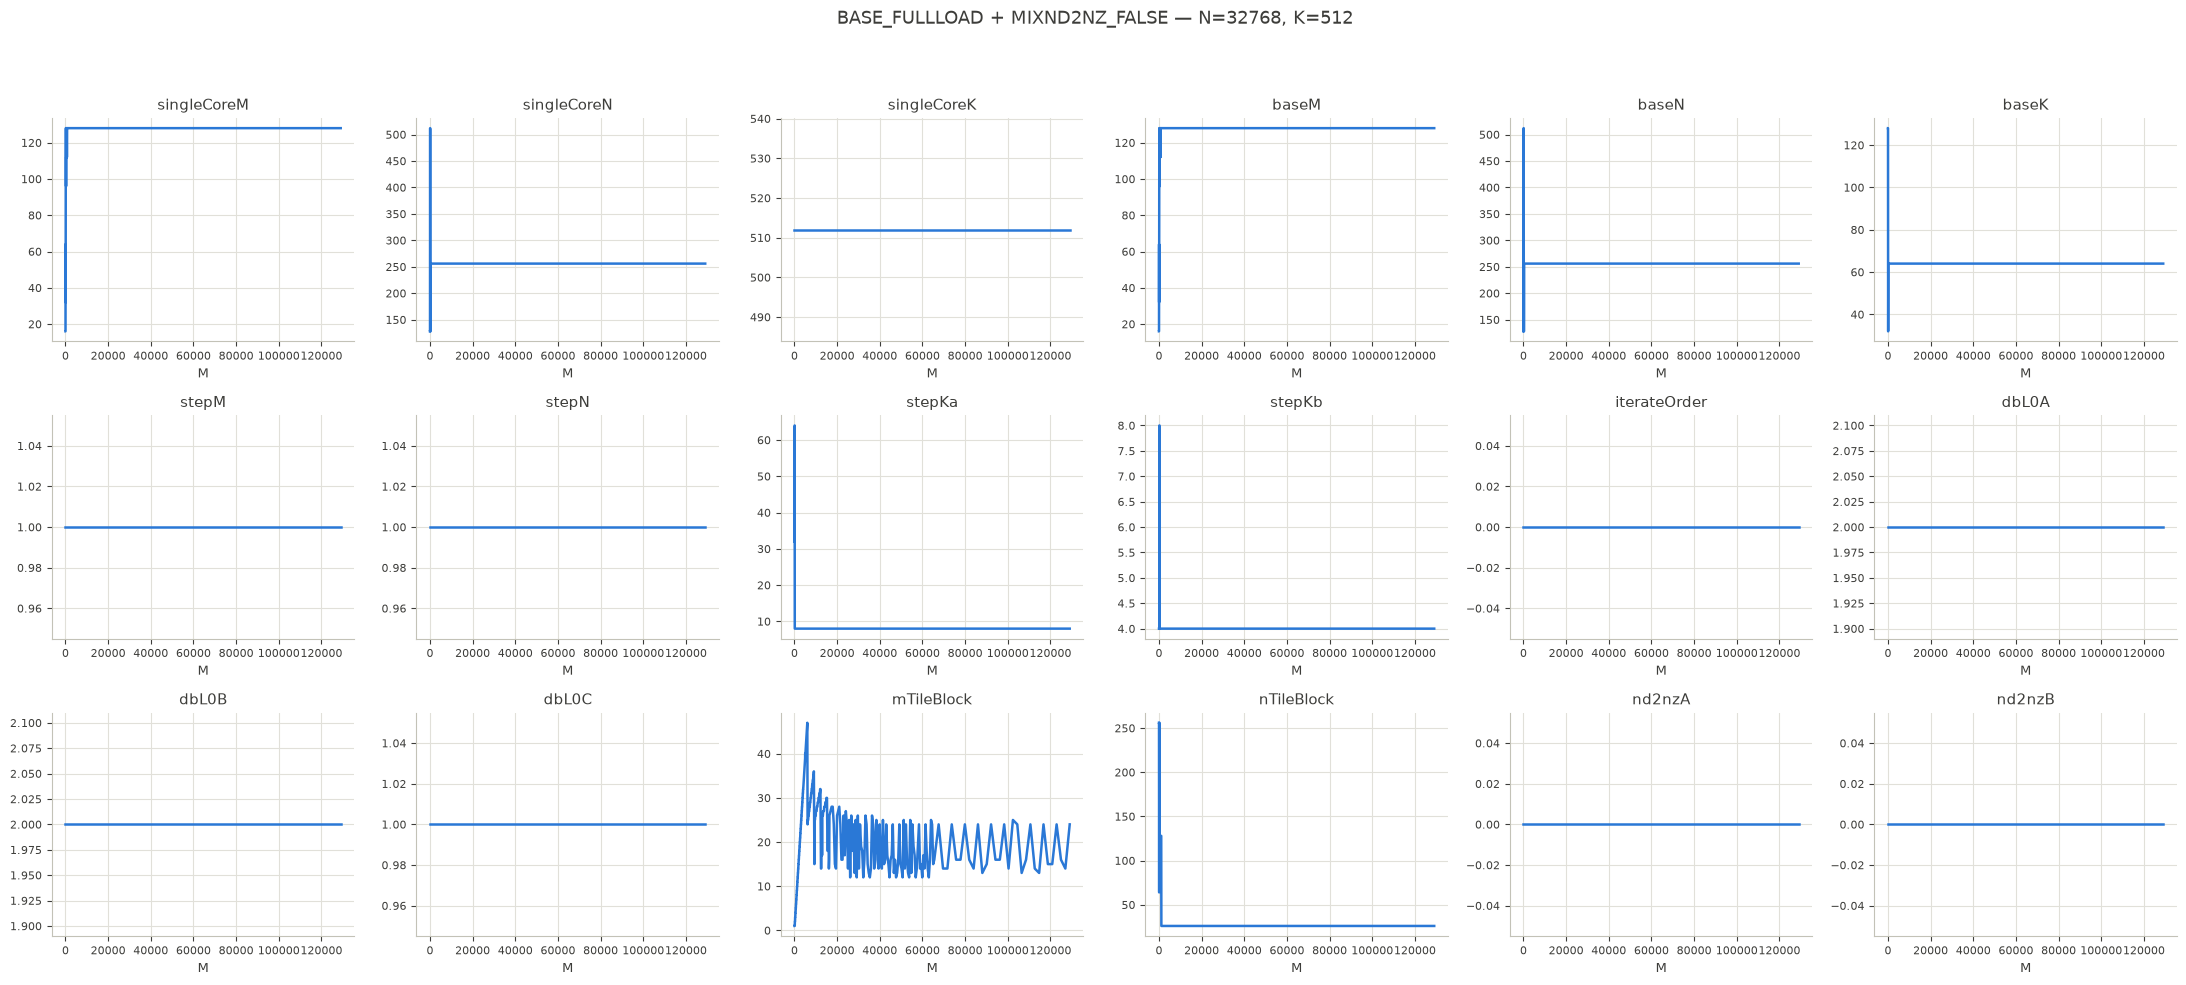

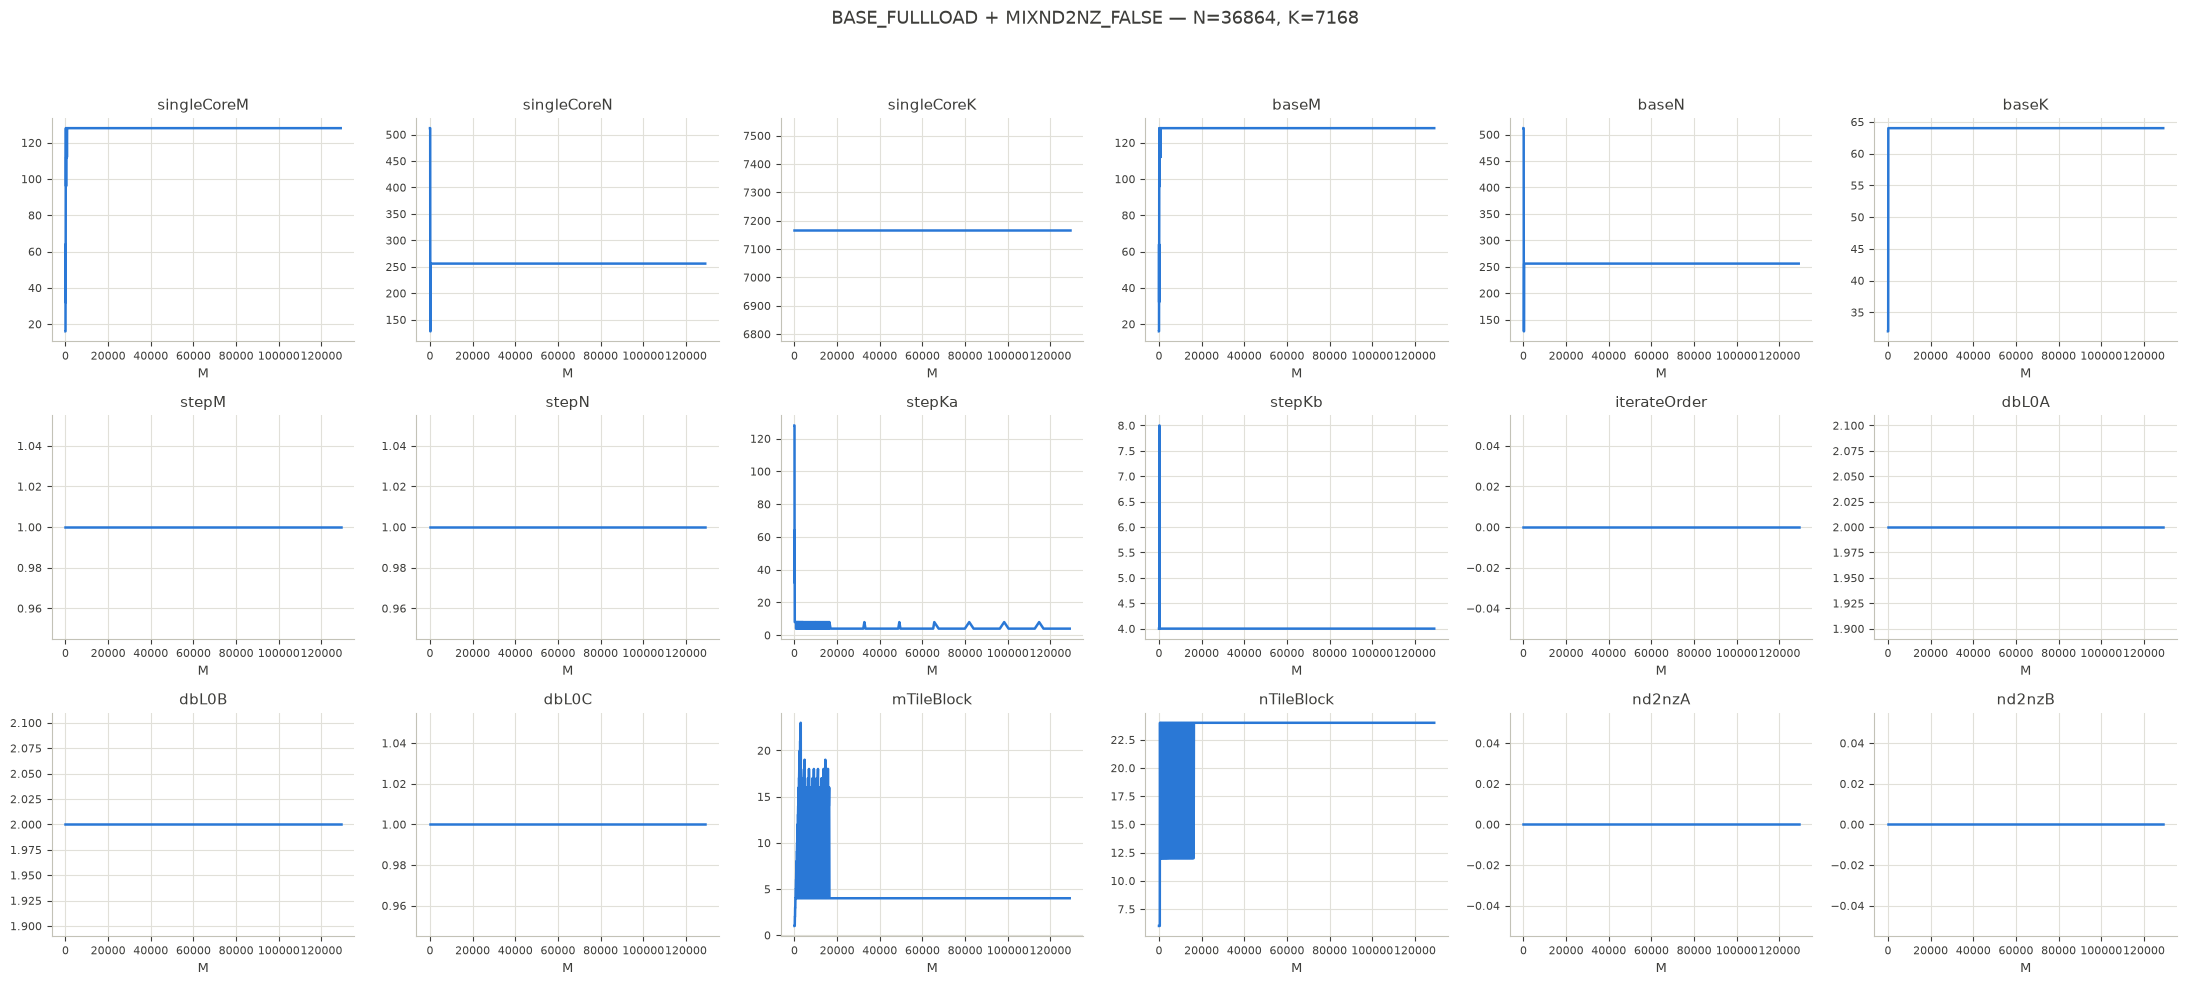

In [17]:
plot_kernel_params(base_fulload)

**Вывод:** при M >= 8192 и N > 256 прослеживается определенный паттерн.
1. $(baseM, baseN, baseK) = (128, 256, 64)$
2. $stepKa \in (4, 8), stepKb = 4$
3. $4 <= mTileBlock <= 35, 2 <= nTileBlock <= 32$

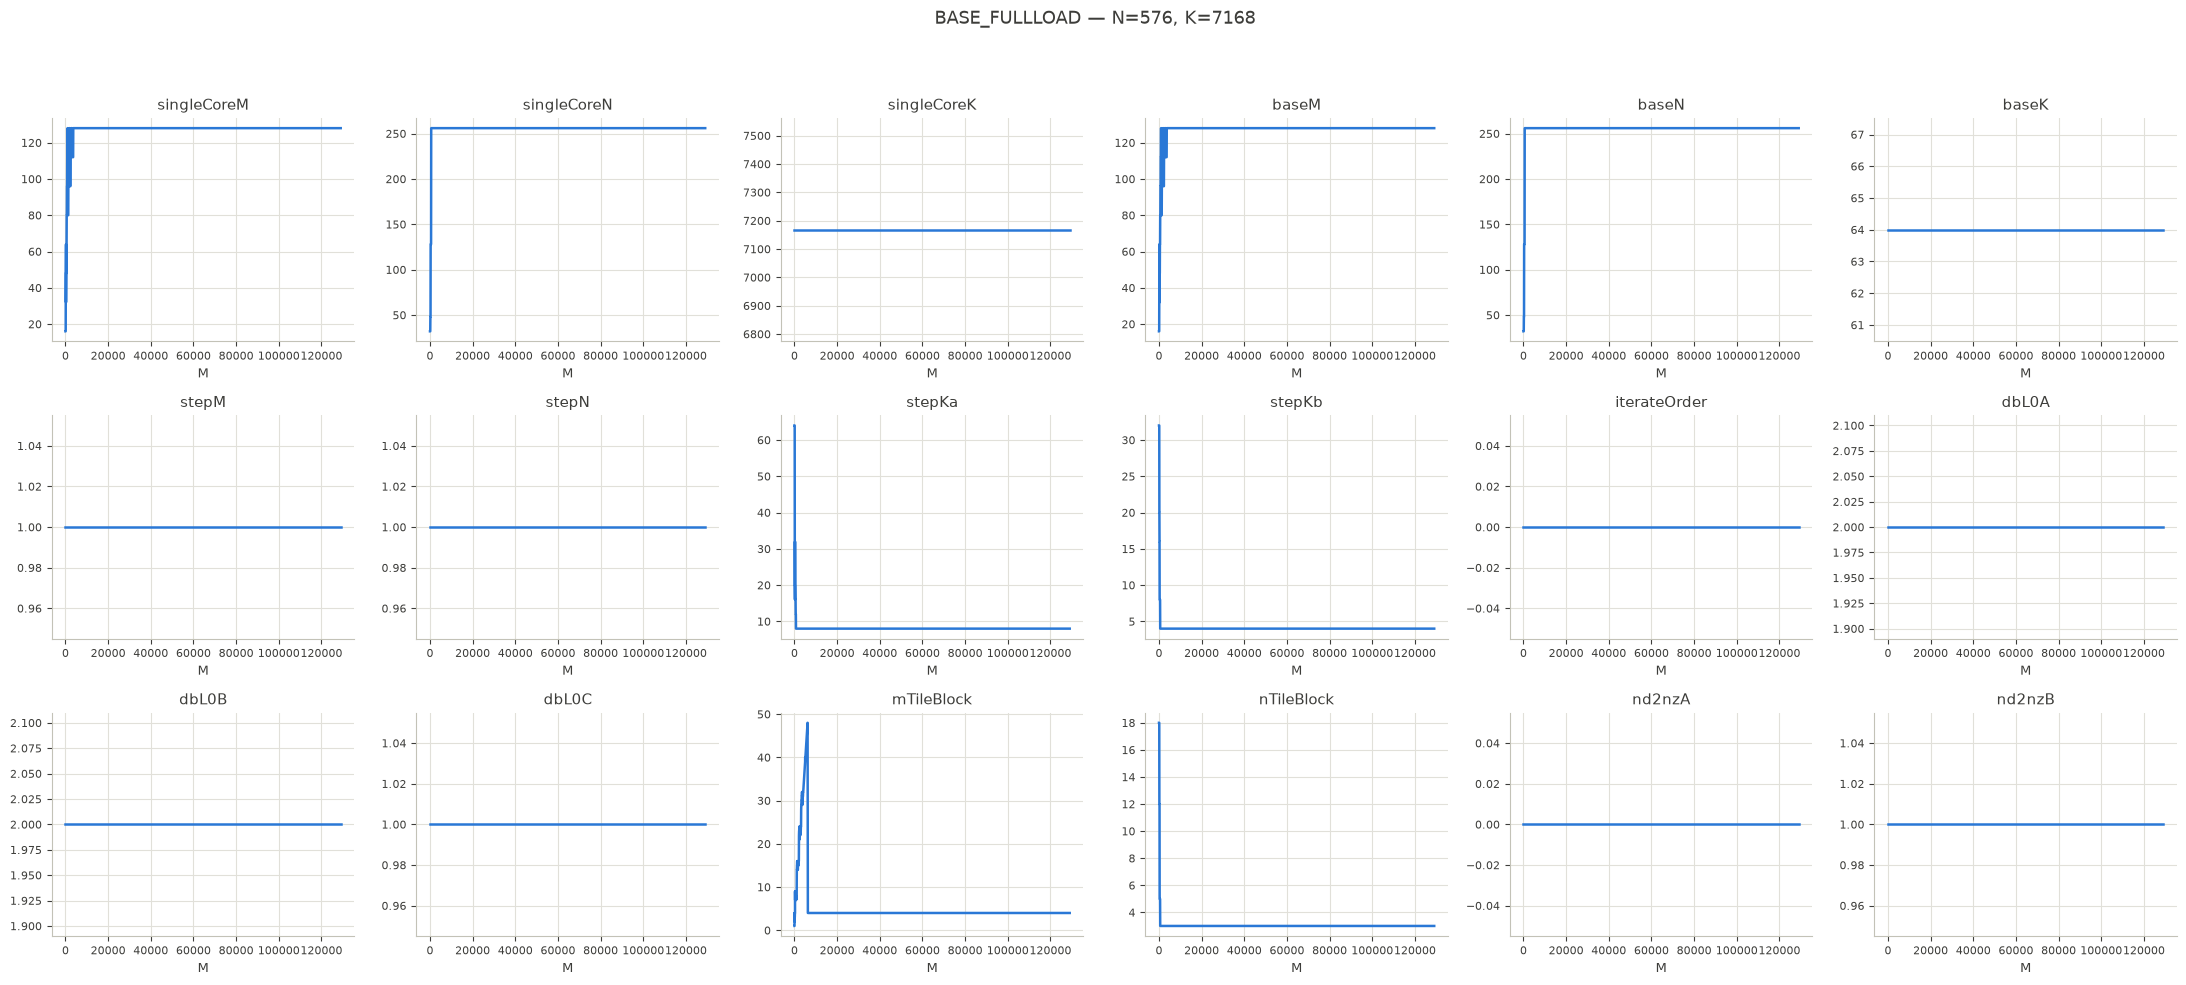

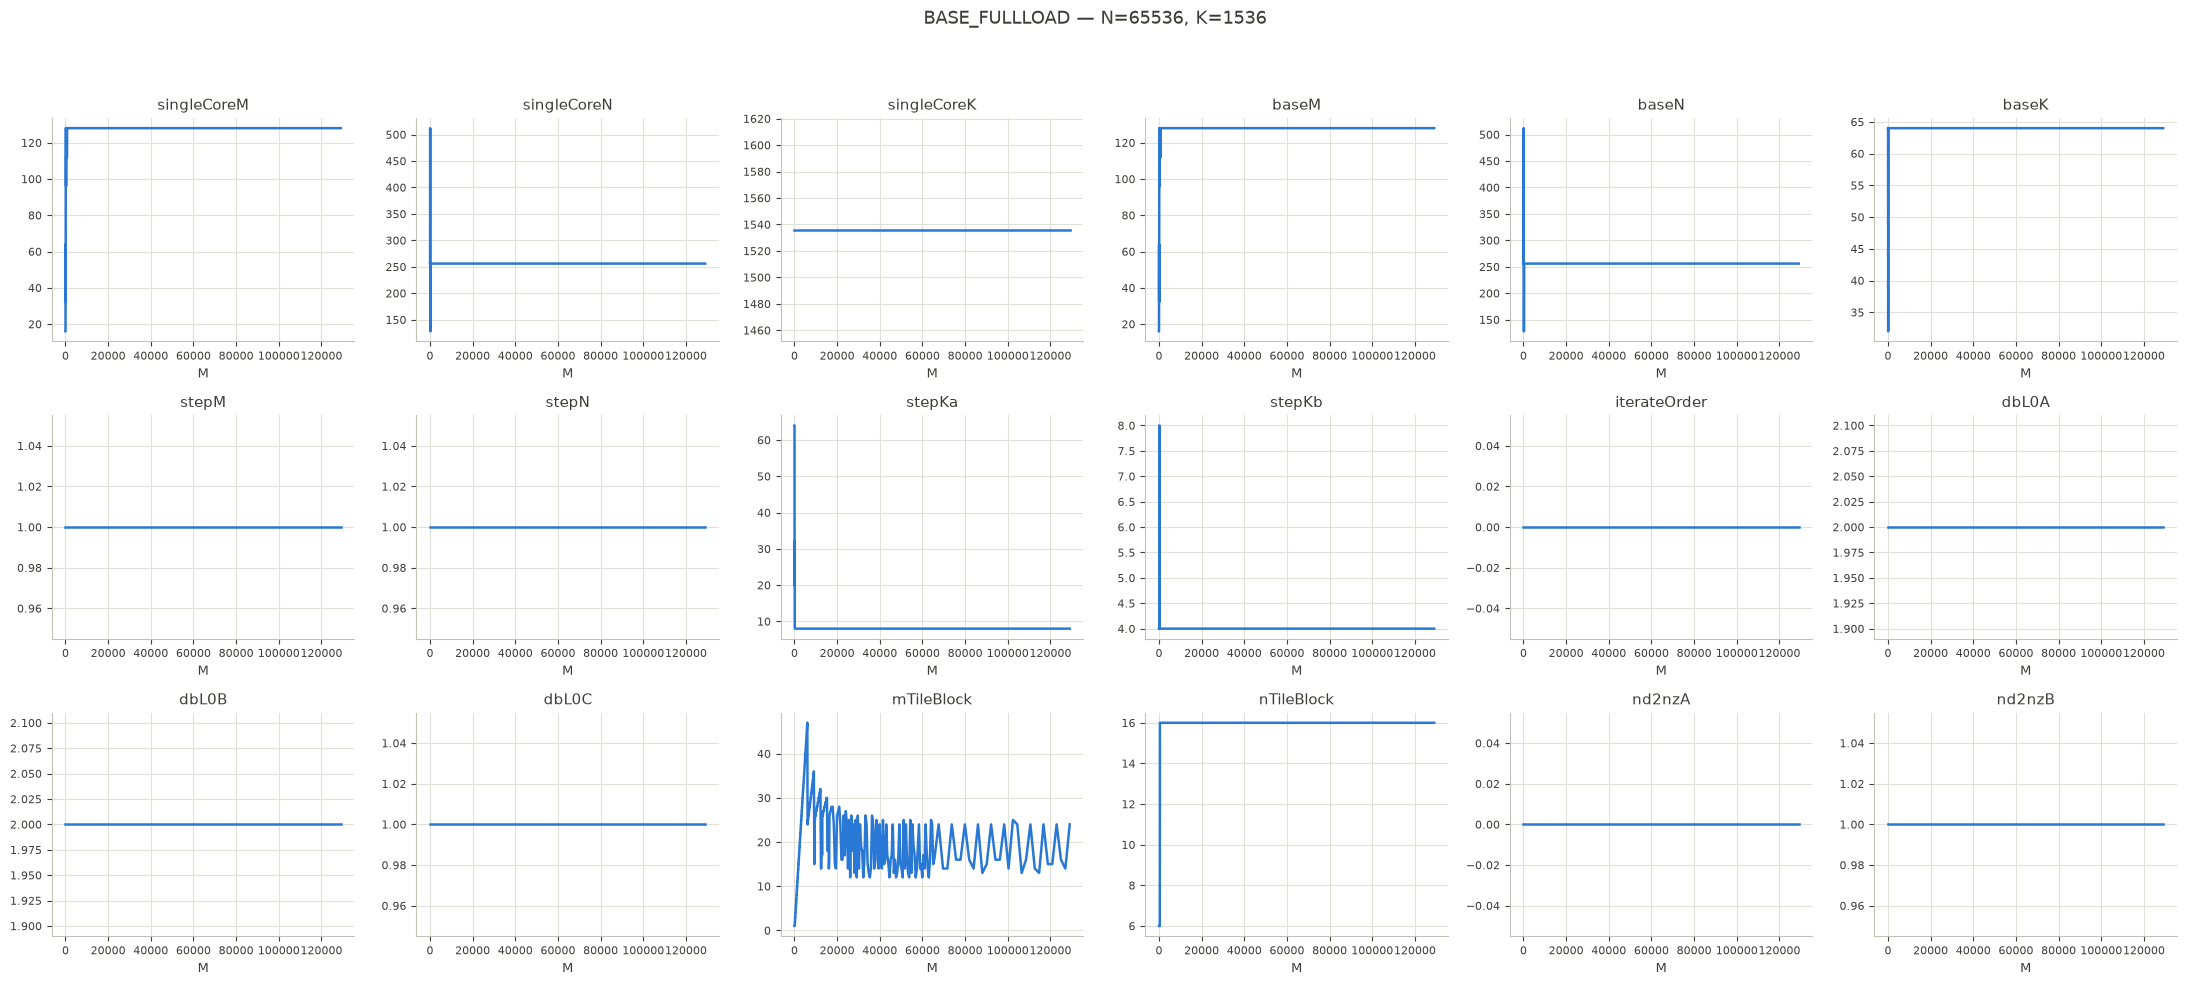

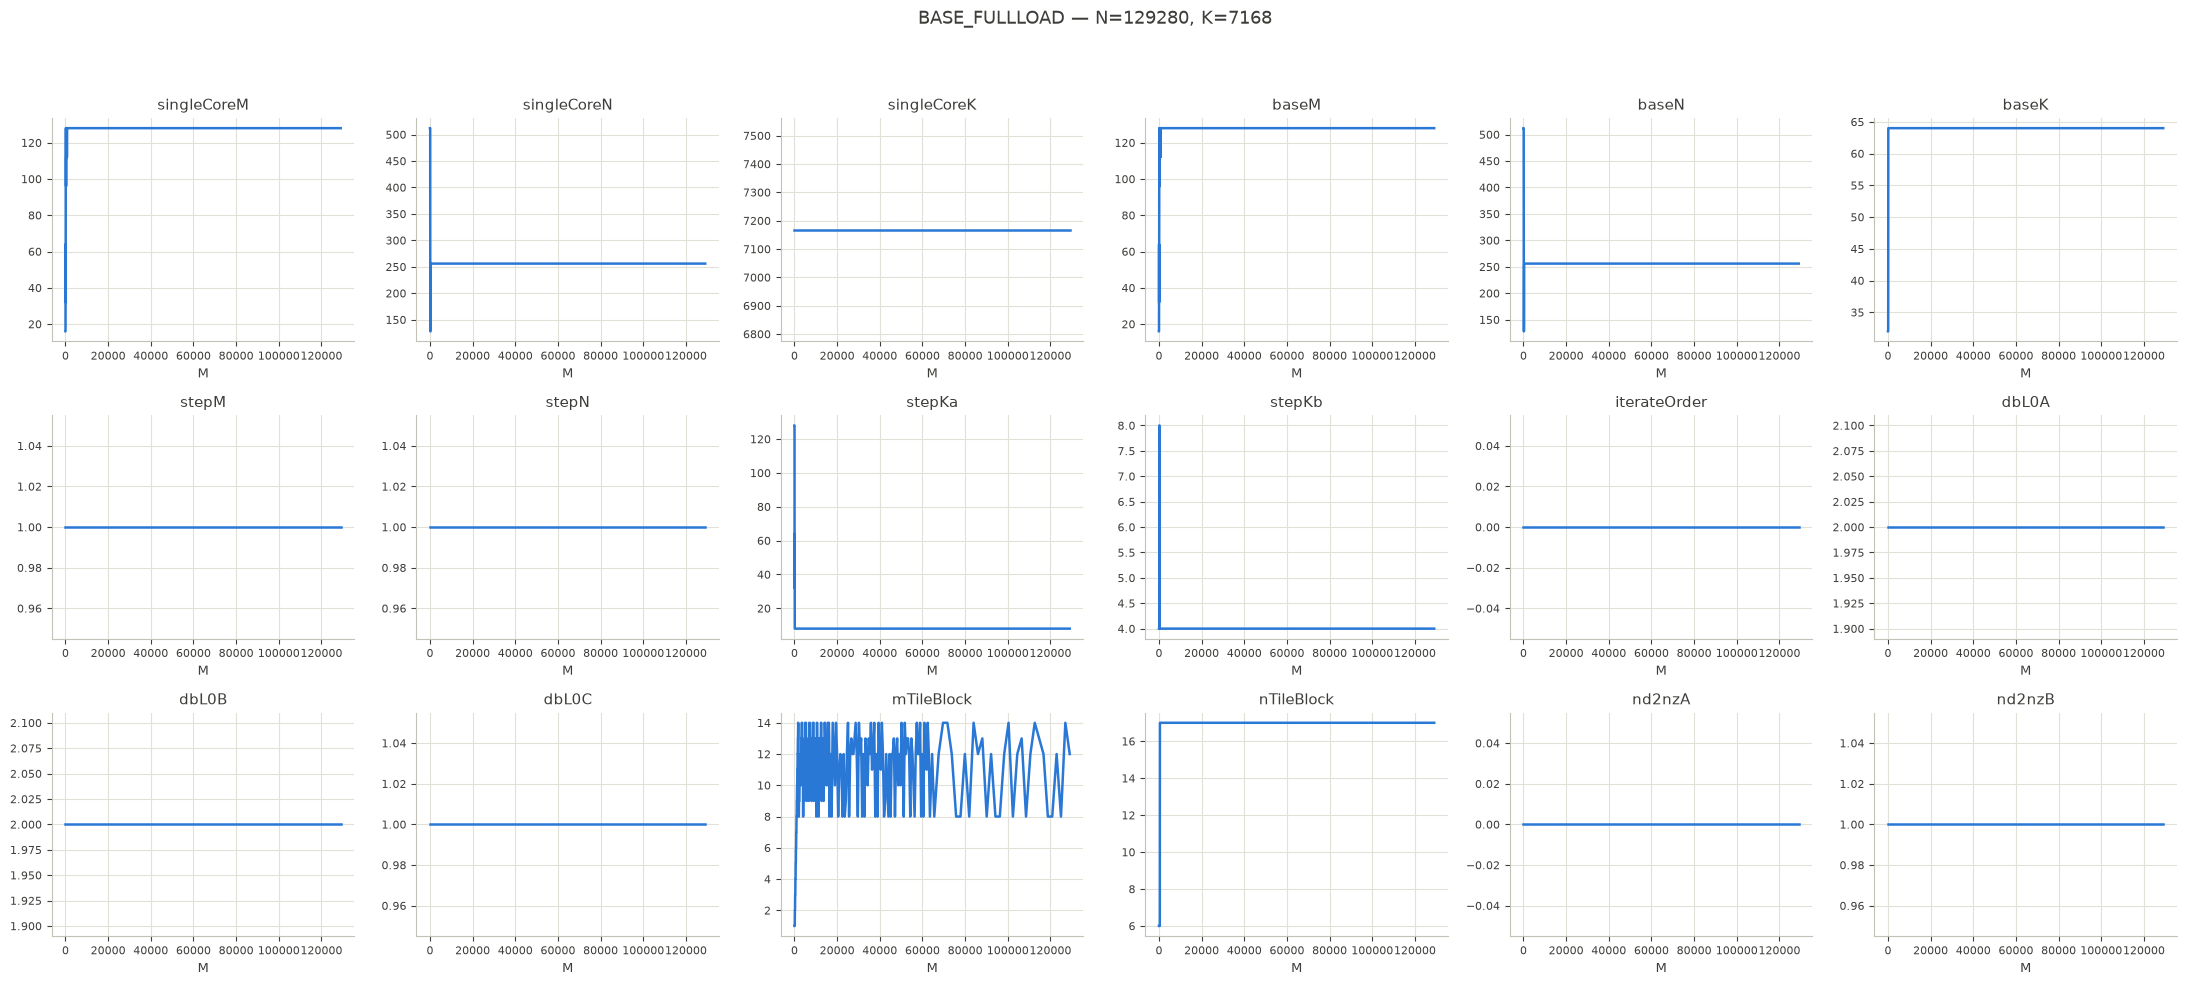

In [18]:
plot_kernel_params(base_fulload_nd2nzB)

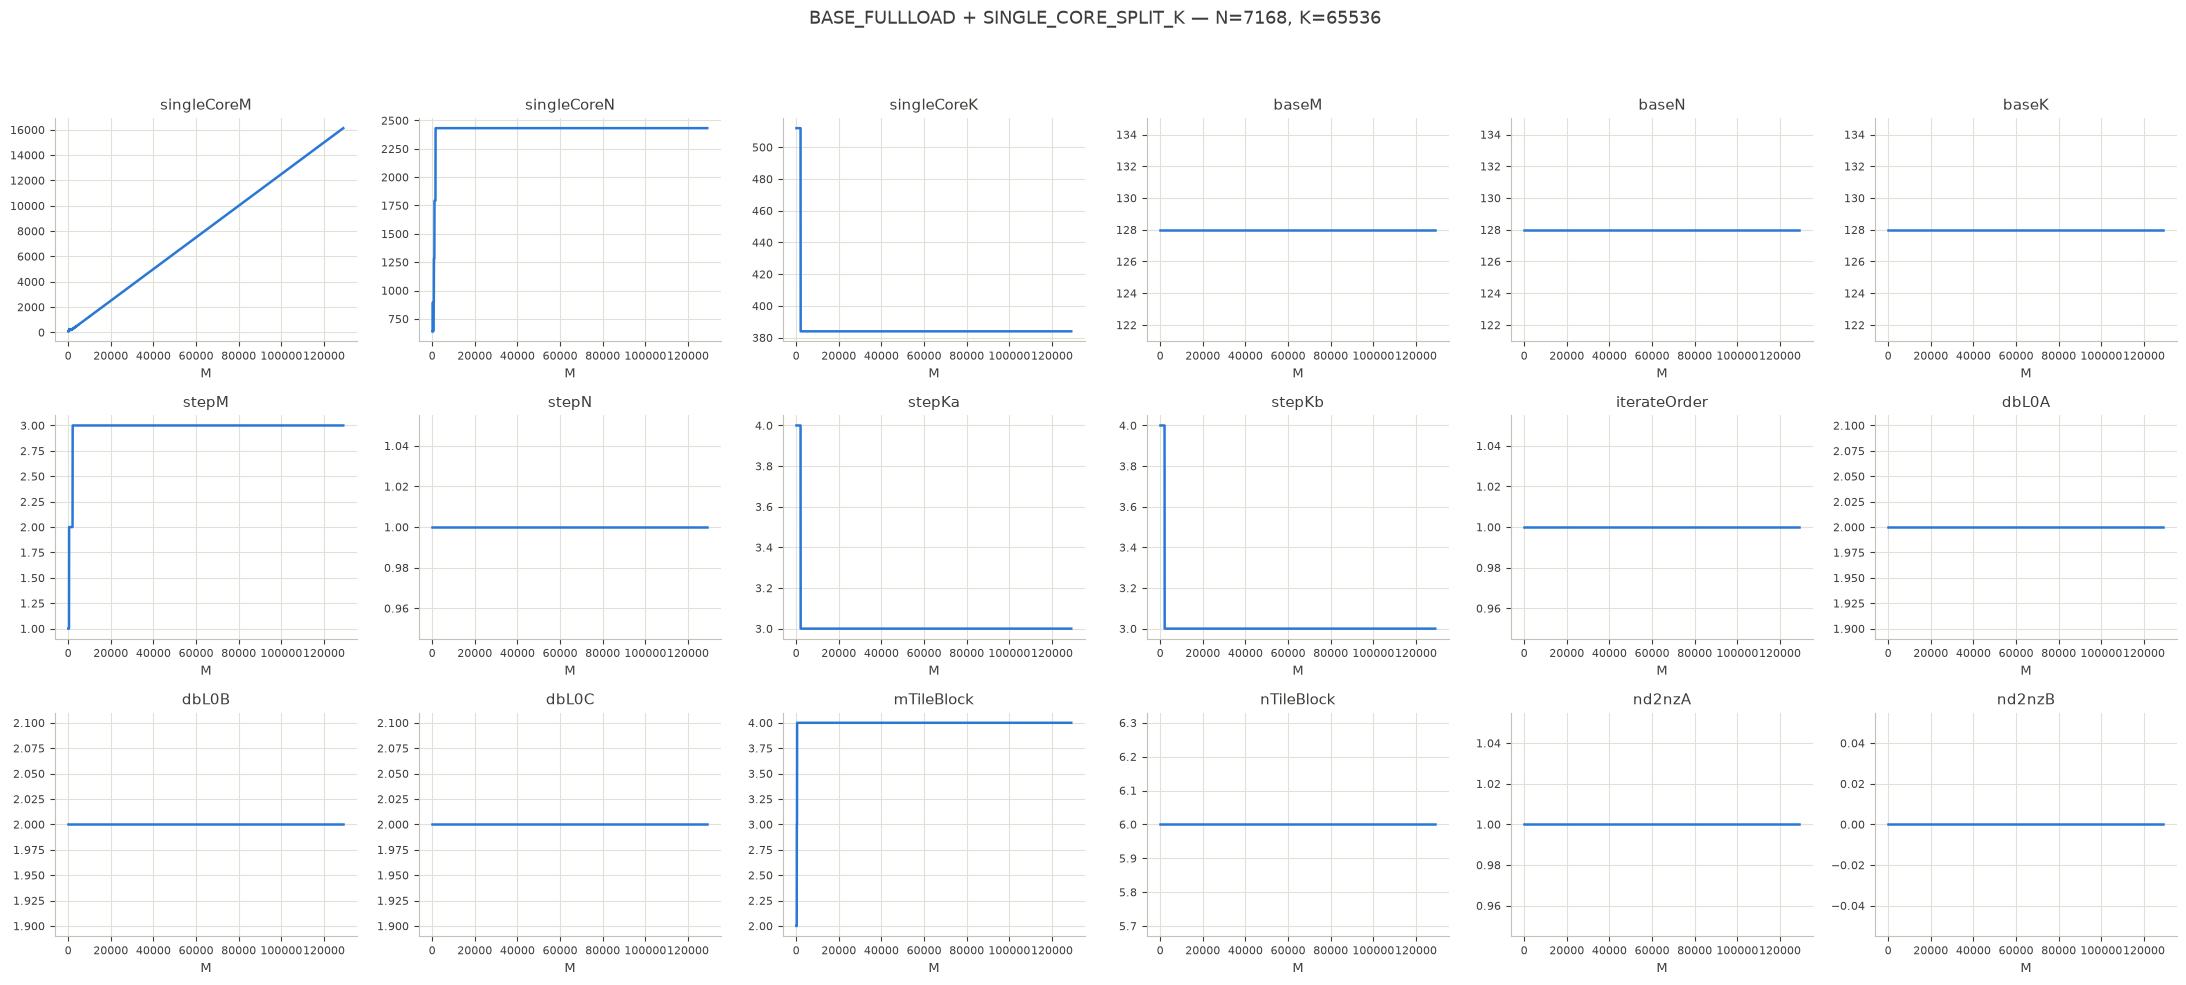

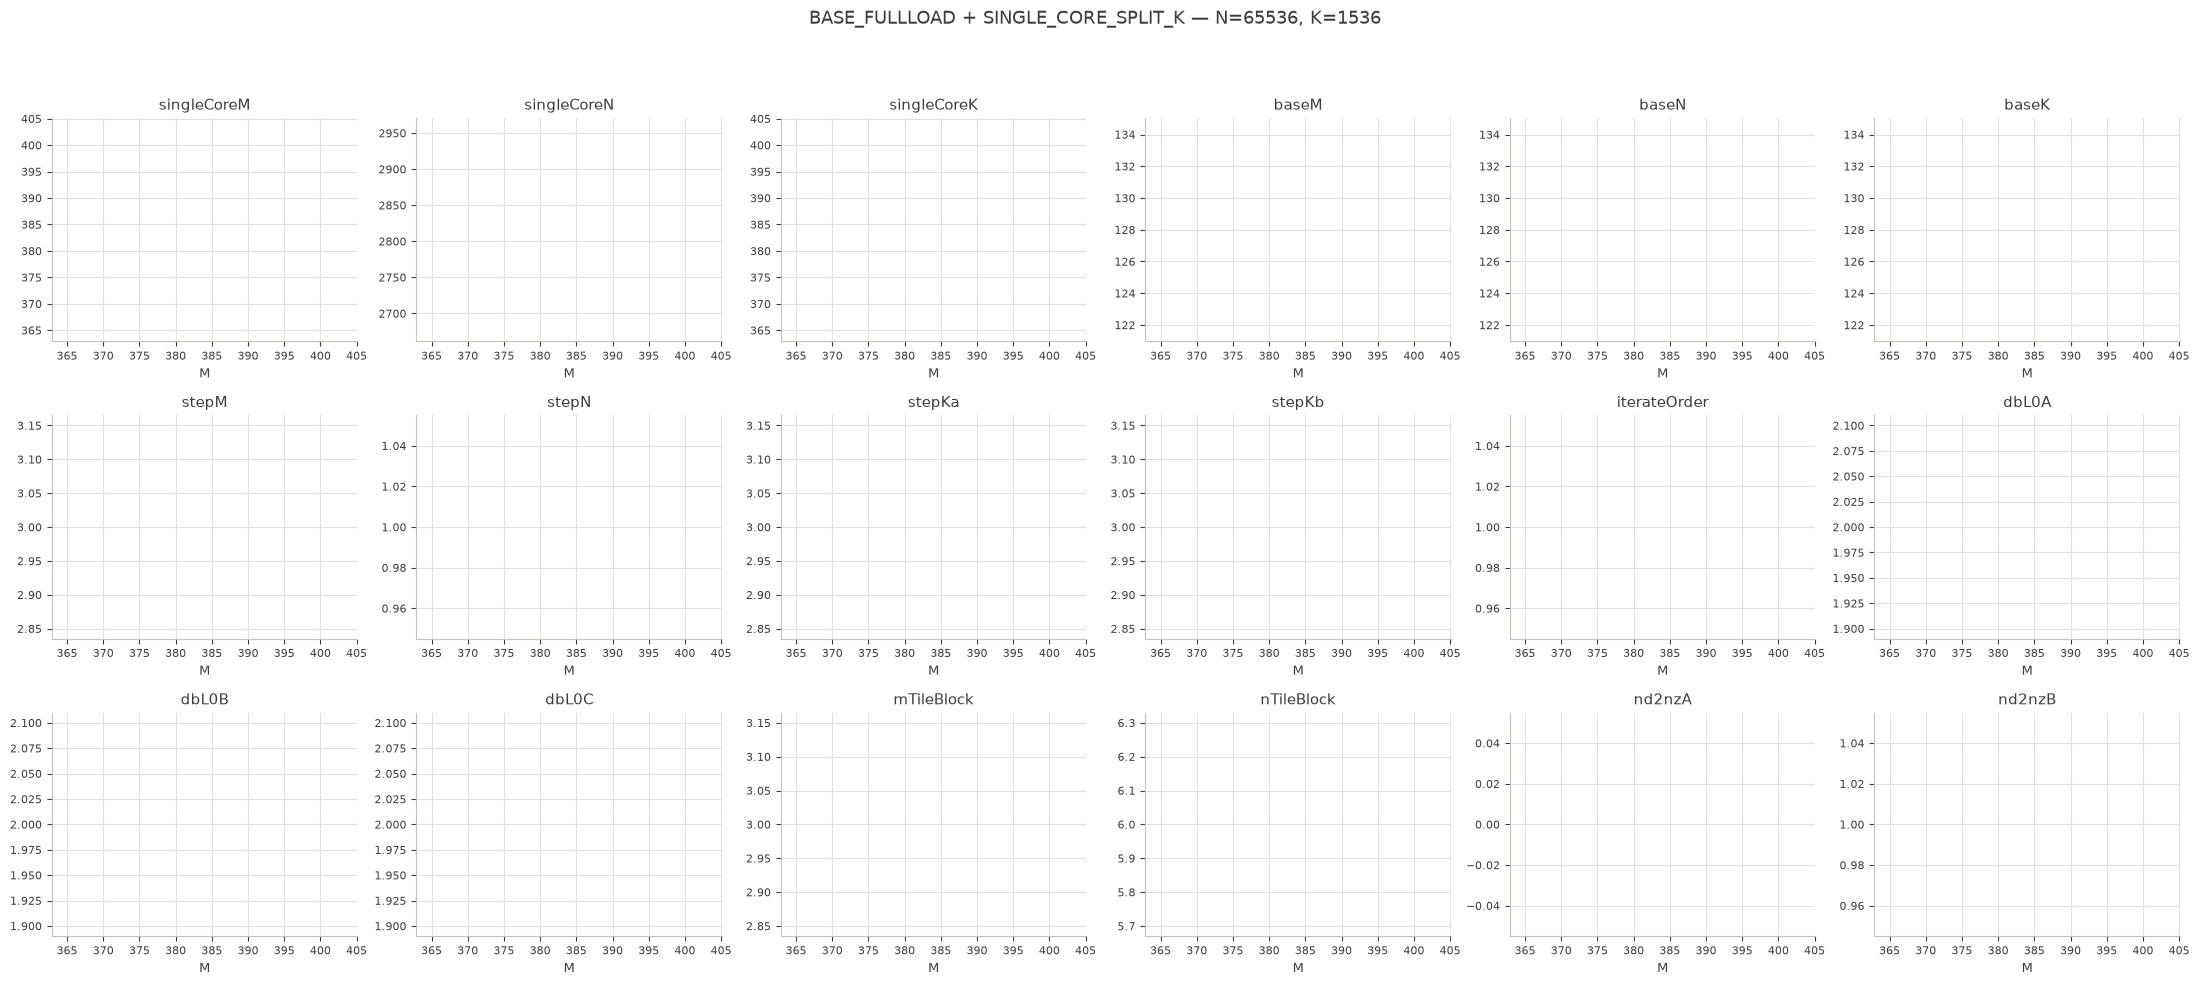

In [19]:
plot_kernel_params(single_split_nd2nzA)

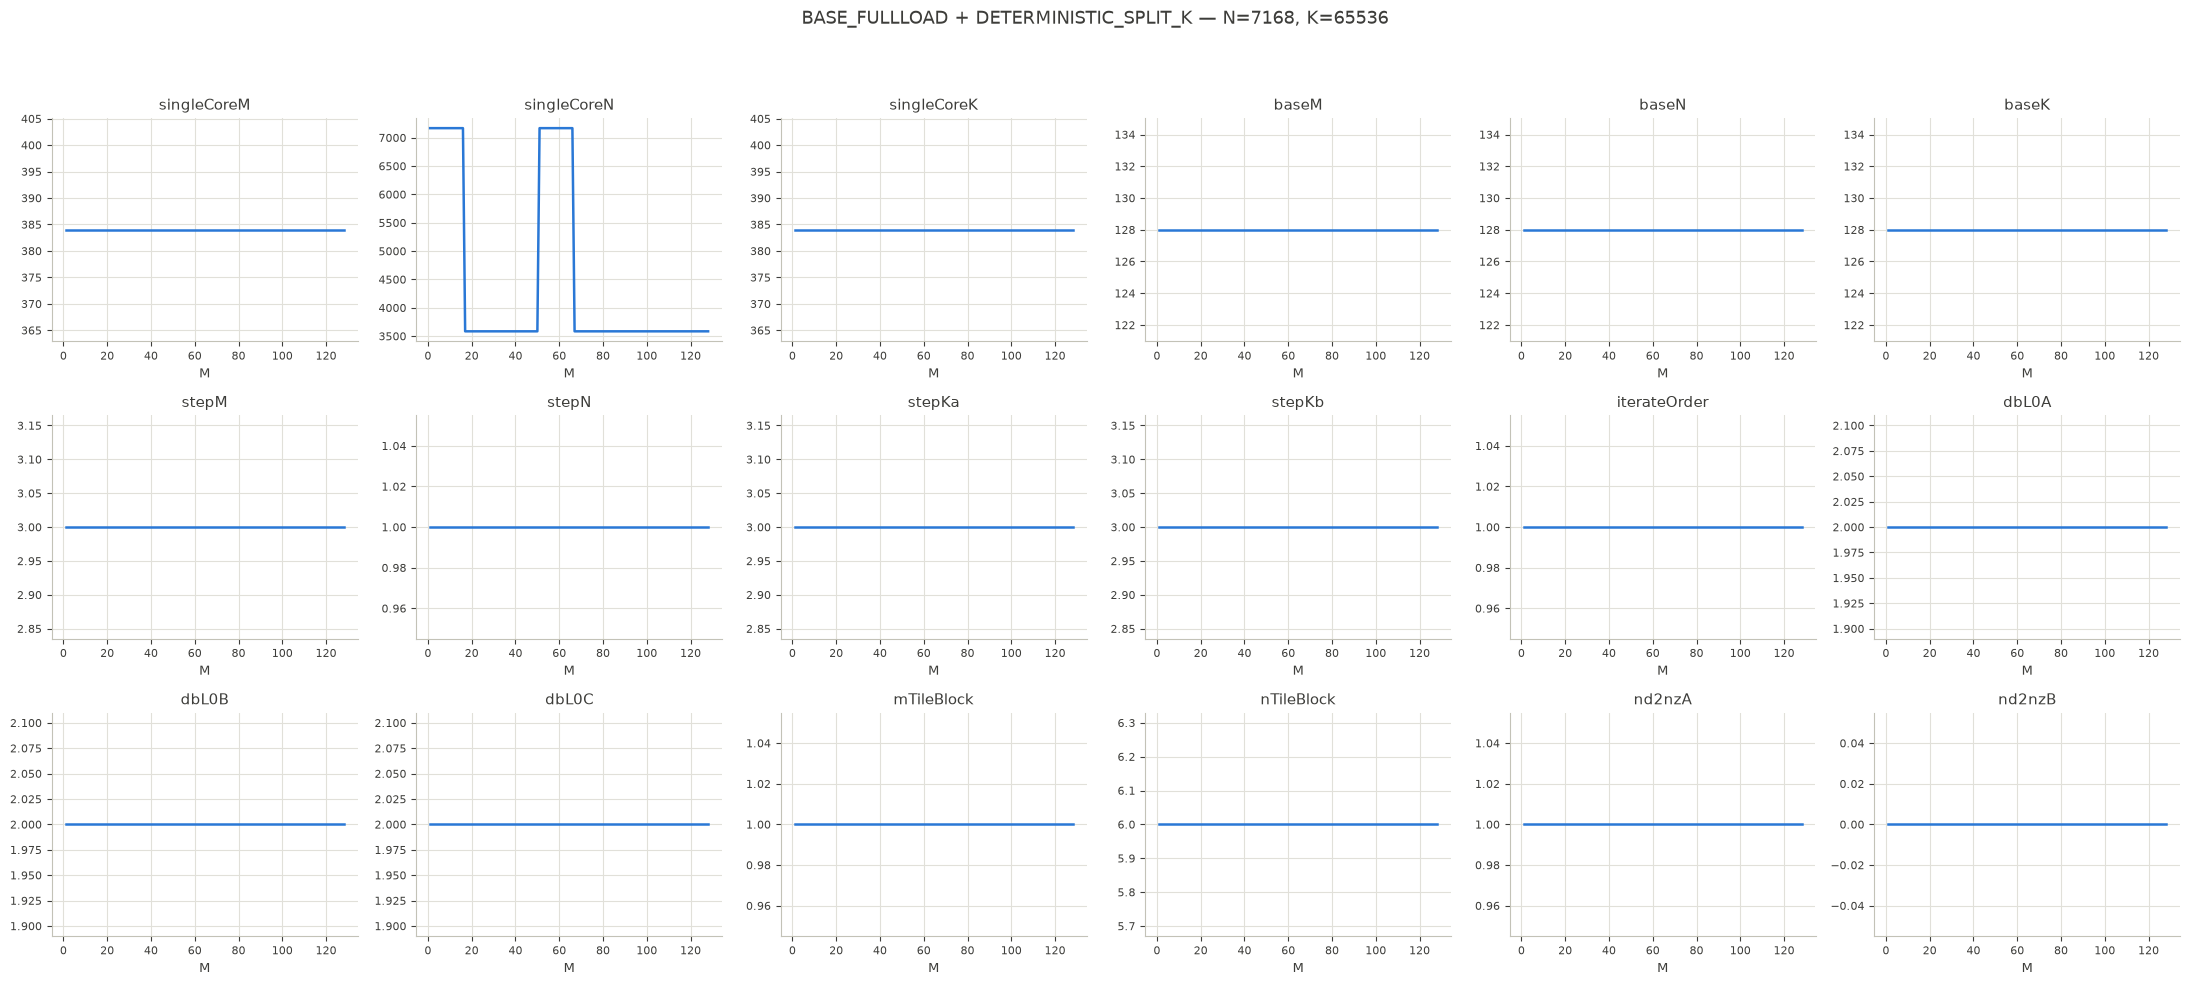

In [20]:
plot_kernel_params(determenistic_split_nd2nzA)

In [21]:
determenistic_split_nd2nzA[determenistic_split_nd2nzA['M'] == 64].values

array([[64, 7168, 65536, 'absorbed_output_proj_decode_64_65536_7168',
        'BASE_FULLLOAD + DETERMINISTIC_SPLIT_K', 48, 384, 7168, 384, 128,
        128, 128, 3, 1, 3, 3, 1, 2, 2, 2, 1, 6, 1, 0]], dtype=object)

In [22]:
determenistic_split_nd2nzA.columns

Index(['M', 'N', 'K', 'case_name', 'kernel', 'tiling_key', 'singleCoreM',
       'singleCoreN', 'singleCoreK', 'baseM', 'baseN', 'baseK', 'stepM',
       'stepN', 'stepKa', 'stepKb', 'iterateOrder', 'dbL0A', 'dbL0B', 'dbL0C',
       'mTileBlock', 'nTileBlock', 'nd2nzA', 'nd2nzB'],
      dtype='str')